# Can a Logistic PINN Forecast U.S. Population?
## What 1790–1940 can—and cannot—tell us about 1940–2026

**Research artifact.** This notebook redevelops the attached *Logistic Population Growth* notebook as a paper-style, reproducible forecasting study. It separates solver accuracy from scientific validity, prevents future-data leakage, and tests standard PINNs, residual-adaptive PINNs, recent-window forecasting models, and a compact DeepONet-style operator.

**Primary question.** Is a logistic PINN trained on population observations from 1790–1940 a defensible way to predict the real U.S. population through 2026? If not, what information set and validation design should be used for a forecast beginning in 2014?

**PINN-centered scope.** The study stays focused on physics-informed and operator-learning questions. It does not replace the PINN analysis with a separate demographic modeling framework. Instead, it identifies what failed in the fixed-logistic PINN and specifies a stronger next-generation PINN experiment based on time-varying coefficients, temporal validation, adaptive collocation, and ensemble uncertainty.

## tl;dr

1. **1790–1940 does not contain enough stable information to forecast the real U.S. population through 2026 under one constant logistic law.** The exact logistic curve fits the 16 early observations well, but its unseen 1950–2020 RMSE is **88.5 million** and its 2026 projection is only **181.3 million**.
2. **The PINN is not the source of the large error.** The exact logistic model, uniform PINN, and residual-adaptive PINN make almost the same long-range forecast because all three impose the same equation. A PINN can solve an assumed equation accurately; it cannot prove that the equation remains valid for another 86 years.
3. **Adaptive sampling improves numerical enforcement, not missing science.** Residual-based adaptive refinement reallocates collocation points where the neural solution violates the ODE most, but it does not materially improve the post-1940 population forecast.
4. **A fair 2014–2026 experiment must stop the information set at 2013.** The notebook trains and selects models only with pre-2014 data, keeps 2014–2025 hidden for final evaluation, and leaves 2026 as a forecast-only year.
5. **Recent annual data are more relevant than equally weighting the entire history.** In the ex-post window diagnostic, a logistic curve fitted to 2004–2013 scores **0.90M RMSE** on 2014–2025, compared with **7.45M** for the all-history logistic fit. The 10-year result is explicitly labeled hindsight evidence, not a model choice that was known in 2013.
6. **Rolling-origin validation is necessary, but regime change remains possible.** The strict pre-2014 validation winner is an all-history Gompertz curve, yet it scores **9.42M RMSE** after 2013. A fixed recent-model median ensemble is more robust at approximately **2.04M RMSE**.
7. **DeepONet does not become well-supported by slicing one national series into overlapping windows.** Its locked 2014–2025 RMSE is **19.6M**. DeepONet becomes a stronger option only when there are genuinely different input functions and output trajectories.
8. **PINN-centered recommendation.** Replace the fixed-parameter logistic law with a **regime-aware inverse PINN** in which the effective growth rate—and, if retained, the saturation scale—can change smoothly over time. Select the data window and regularization through rolling-origin validation, use adaptive sampling only after model structure is justified, and report a multi-seed ensemble rather than one neural forecast.
9. **Operational 2026 benchmark.** After legitimately refitting through 2025, the transparent recent-model median ensemble projects **342.813 million**, with an empirical 90% interval of **[340.505, 345.121] million**. This is a separate one-year-ahead question, not a reconstruction of what could have been known in 2013.

## Context & Methods

### The study asks three different forecasting questions

| Experiment | Forecast origin we pretend to stand at | Data the model is allowed to use | Years hidden from fitting and selection | What the experiment means |
|---|---:|---|---|---|
| **A. Historical logistic stress test** | End of 1940 | Decennial population, 1790–1940 | 1950–2020; 2026 is forecast only | Tests whether one pre-1940 logistic law remains valid far outside its calibration period |
| **B. Retrospective modern forecast** | End of 2013 | Annual population through 2013 | 2014–2025; 2026 is forecast only | Tests what a forecaster could honestly have attempted before 2014 |
| **C. Current short-horizon forecast** | After the 2025 estimate | Annual population through 2025 | 2026 | Produces a legitimate one-year-ahead 2026 benchmark |

These are not interchangeable. Using 2025 data for Experiment B would be leakage. Using 2025 data for Experiment C is correct because 2025 is before that forecast origin.

### Research questions and falsifiable tests

| Question | Test | Decision criterion |
|---|---|---|
| Can 1790–1940 predict the real post-1940 path? | Fit only through 1940; score genuinely unseen observations from 1950 onward | Out-of-sample error and structural stability, not training loss |
| Does a PINN add information beyond the logistic equation? | Compare the exact logistic solution with a neural solution constrained by the identical ODE | The PINN must improve unseen forecast accuracy, not merely reproduce the same curve |
| Does adaptive sampling help? | Compare uniform collocation with residual-based adaptive refinement | Improvement in forecast error, not only reduction in ODE residual |
| What data should forecast 2014–2026? | Annual data, candidate history windows, rolling-origin validation, and a locked 2014–2025 holdout | No future leakage; separate preselected winners from hindsight diagnostics |
| Does DeepONet help? | Train a branch–trunk history-to-horizon operator using only pre-cutoff rolling windows | Strict temporal validation and final holdout performance |
| What is the next PINN experiment? | Formulate a time-varying-coefficient inverse PINN and define a leakage-free evaluation plan | Better held-out forecasts with stable learned coefficient functions and calibrated uncertainty |

### Key assumptions

1. **Forecast origin controls what is legal to use.** A forecast beginning in 2014 may use data only through 2013. A forecast for 2026 made after the 2025 estimate may use data through 2025.
2. **Solver accuracy and model validity are different questions.** A small physics residual means the network follows the chosen equation. It does not mean that the chosen equation describes the real population process outside the training period.
3. **Backtests should imitate deployment.** Windows and hyperparameters are selected only on dates before the final holdout. Any model discovered by inspecting 2014–2025 is labeled an ex-post diagnostic.
4. **Aggregate population is nonstationary.** A constant growth rate and constant carrying capacity are strong assumptions over a 236-year span. The notebook tests rather than presumes their stability.
5. **2026 is not treated as observed.** The Census short-term projection is used only as an external comparison for the current one-year-ahead forecast.

### Audit of the attached notebook

The source notebook correctly notices that a logistic PINN trained through 1940 fails after 1940, and it also recognizes that fitting on all available years and evaluating on the same years is not forecasting. The redevelopment keeps those useful observations but turns them into a controlled research design.

The original executed baseline learned approximately \(r=0.0322\,\text{yr}^{-1}\) and \(K=184.5\) million, and projected roughly 177 million in 2026. That result is not mainly a neural-network failure: it is the numerical consequence of extending a fixed logistic law far beyond the period that identified it.

The revised notebook fixes five methodological problems:

1. It never labels an assumed 2026 population as an observed value.
2. It compares the PINN with the exact solution of the same logistic ODE, so solver behavior is not confused with model behavior.
3. It uses decennial data for the 1940-origin historical stress test but annual data for the 2013-origin modern forecast.
4. It separates strict pre-2014 model selection from ex-post diagnostics on 2014–2025.
5. It tests adaptive sampling and DeepONet by forecast error, not by architecture complexity or training loss alone.

### Literature and methodological position

PINNs combine a data-matching loss with a differential-equation residual (Raissi, Perdikaris & Karniadakis, 2019). They are especially useful when the equation is informative, when observations are sparse, or when unknown physical parameters must be inferred. They can also suffer from optimization and spectral-bias failure modes (Krishnapriyan et al., 2021).

Residual-based adaptive methods such as RAD and RAR-D move collocation points toward regions where the current neural solution violates the governing equation most strongly (Wu et al., 2023). This is a numerical strategy: it improves where the ODE is enforced. It does not decide whether the ODE is the right long-range description.

DeepONet learns nonlinear **operators** from an input function to an output function through branch and trunk networks (Lu et al., 2021). Its natural use is a family of related problems: many coefficient functions, many initial conditions, many systems, or many simulated trajectories. Overlapping windows from one U.S. population series increase the number of training pairs but not the number of independent population systems.

A PINN-centered extension of this study should therefore change the governing model rather than only the optimizer. One candidate is a regime-aware inverse PINN,

\[
\frac{dP}{dt}=r_\phi(t)P\left(1-\frac{P}{K_\phi(t)}\right),
\]

where \(r_\phi(t)\) and, if needed, \(K_\phi(t)\) are positive, slowly varying functions learned from data. Smoothness, identifiability, and extrapolation constraints must be regularized and selected through rolling-origin validation. This notebook treats that as the next research design—not as a result already proven by the current aggregate series.

### How to interpret every result in this notebook

The notebook uses a three-level test:

1. **Numerical test:** Did the neural network satisfy the differential equation?
2. **Calibration test:** Did the equation fit the observations used for training?
3. **Forecast test:** Did the equation predict observations that were unavailable during training or selection?

A PINN may pass the first two tests and fail the third. Adaptive sampling primarily targets the first test. The scientific claim depends on the third.

A simple analogy is useful: the PINN is a careful calculator, and adaptive sampling tells the calculator where to work harder. Neither one can make an incorrect forecasting equation become correct.

### 1. Reproducible setup

**What this cell does.** It imports the scientific-Python stack, fixes random seeds, limits PyTorch to one CPU thread, records package versions, and creates a deterministic output directory.

**Why this matters.** Forecast comparisons are meaningful only when they can be rerun. PINN and DeepONet training can change with random initialization, so the notebook controls the environment and later reports multi-seed behavior where appropriate.

In [1]:
from __future__ import annotations

import io
import json
import math
import platform
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from IPython.display import Markdown, display
from scipy.optimize import least_squares
from statsmodels.tsa.holtwinters import Holt
import statsmodels
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

OUTPUT_DIR = (Path.cwd().resolve() / "population_forecasting_outputs_revised")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory: {Path.cwd().resolve()}")
print(f"Output directory: {OUTPUT_DIR}")

plt.rcParams.update({
    "figure.figsize": (10, 5.8),
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
    "axes.titleweight": "bold",
})

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "SciPy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "PyTorch": torch.__version__,
}, name="version")
display(versions.to_frame())

Working directory: /mnt/data
Output directory: /mnt/data/population_forecasting_outputs_revised


,version
Python,3.13.5
NumPy,2.3.5
pandas,2.2.3
SciPy,1.17.0
statsmodels,0.14.6
PyTorch,2.10.0+cpu


## Data

### 2. Load an offline, source-traceable data snapshot

**What this cell does.** It loads two population series embedded directly in the notebook:

- **Decennial census counts, 1790–2020**, used for the deliberately severe 1940-origin extrapolation test.
- **Annual July 1 population estimates, 1900–2025**, used for modern rolling-origin forecasts and the 2013 cutoff.

The July 1, 2026 Census value is retained only as a short-term projection benchmark. It is never used as an observed training or test target.

**Why two data grains are necessary.** The 1790–1940 question is historical and has only decennial measurements. The 2014–2026 question concerns recent dynamics; reducing that problem to one observation every ten years would discard the very information needed to estimate the current growth regime.

In [2]:
DECENNIAL_CSV = 'year,population,population_millions\n1790,3929214,3.929214\n1800,5308483,5.308483\n1810,7239881,7.239881\n1820,9638453,9.638453\n1830,12866020,12.86602\n1840,17069453,17.069453\n1850,23191876,23.191876\n1860,31443321,31.443321\n1870,38558371,38.558371\n1880,50189209,50.189209\n1890,62979766,62.979766\n1900,76212168,76.212168\n1910,92228496,92.228496\n1920,106021568,106.021568\n1930,123202660,123.20266\n1940,132165129,132.165129\n1950,151325798,151.325798\n1960,179323175,179.323175\n1970,203211926,203.211926\n1980,226545805,226.545805\n1990,248709873,248.709873\n2000,281421906,281.421906\n2010,308745538,308.745538\n2020,331449281,331.449281\n'
ANNUAL_CSV = 'year,population,source_segment,population_millions,annual_change_millions,growth_rate_pct\n1900,76094000,Census historical national estimates 1900-1999,76.094,,\n1901,77584000,Census historical national estimates 1900-1999,77.584,1.490000000000009,1.9581044497595013\n1902,79163000,Census historical national estimates 1900-1999,79.163,1.5789999999999935,2.03521344607136\n1903,80632000,Census historical national estimates 1900-1999,80.632,1.4690000000000083,1.8556648939529907\n1904,82166000,Census historical national estimates 1900-1999,82.166,1.5339999999999918,1.902470483182861\n1905,83822000,Census historical national estimates 1900-1999,83.822,1.656000000000006,2.0154321738918846\n1906,85450000,Census historical national estimates 1900-1999,85.45,1.6280000000000001,1.9422108754264977\n1907,87008000,Census historical national estimates 1900-1999,87.008,1.5579999999999927,1.8232884727910958\n1908,88710000,Census historical national estimates 1900-1999,88.71,1.7019999999999982,1.9561419639573474\n1909,90490000,Census historical national estimates 1900-1999,90.49,1.7800000000000011,2.0065381580430586\n1910,92407000,Census historical national estimates 1900-1999,92.407,1.9170000000000016,2.118466128854024\n1911,93863000,Census historical national estimates 1900-1999,93.863,1.456000000000003,1.5756382092265708\n1912,95335000,Census historical national estimates 1900-1999,95.335,1.4719999999999942,1.568243077677045\n1913,97225000,Census historical national estimates 1900-1999,97.225,1.8900000000000006,1.982482823726861\n1914,99111000,Census historical national estimates 1900-1999,99.111,1.88600000000001,1.939830290563127\n1915,100546000,Census historical national estimates 1900-1999,100.546,1.4350000000000023,1.4478715783313723\n1916,101961000,Census historical national estimates 1900-1999,101.961,1.414999999999992,1.4073160543432772\n1917,103268000,Census historical national estimates 1900-1999,103.268,1.3070000000000022,1.281862672982803\n1918,103208000,Census historical national estimates 1900-1999,103.208,-0.060000000000002274,-0.05810125111360698\n1919,104514000,Census historical national estimates 1900-1999,104.514,1.3059999999999974,1.2654057824974752\n1920,106461000,Census historical national estimates 1900-1999,106.461,1.9470000000000027,1.8629083185027762\n1921,108538000,Census historical national estimates 1900-1999,108.538,2.076999999999998,1.9509491738758822\n1922,110049000,Census historical national estimates 1900-1999,110.049,1.51100000000001,1.3921391586356746\n1923,111947000,Census historical national estimates 1900-1999,111.947,1.8979999999999961,1.724686276113374\n1924,114109000,Census historical national estimates 1900-1999,114.109,2.161999999999992,1.931271047906602\n1925,115829000,Census historical national estimates 1900-1999,115.829,1.7199999999999989,1.5073307101105105\n1926,117397000,Census historical national estimates 1900-1999,117.397,1.568000000000012,1.3537197074998453\n1927,119035000,Census historical national estimates 1900-1999,119.035,1.637999999999991,1.3952656371116756\n1928,120509000,Census historical national estimates 1900-1999,120.509,1.4740000000000038,1.2382912588734474\n1929,121767000,Census historical national estimates 1900-1999,121.767,1.2579999999999956,1.0439054344488774\n1930,123076741,Census historical national estimates 1900-1999,123.076741,1.3097410000000025,1.075612440152085\n1931,124039648,Census historical national estimates 1900-1999,124.039648,0.9629070000000013,0.7823630949084004\n1932,124840471,Census historical national estimates 1900-1999,124.840471,0.8008229999999941,0.6456185686692706\n1933,125578763,Census historical national estimates 1900-1999,125.578763,0.7382920000000013,0.591388348735089\n1934,126373773,Census historical national estimates 1900-1999,126.373773,0.7950100000000049,0.6330767886286726\n1935,127250232,Census historical national estimates 1900-1999,127.250232,0.876458999999997,0.6935450126981602\n1936,128053180,Census historical national estimates 1900-1999,128.05318,0.8029480000000007,0.6309992425004074\n1937,128824829,Census historical national estimates 1900-1999,128.824829,0.7716489999999965,0.6026004196069135\n1938,129824939,Census historical national estimates 1900-1999,129.824939,1.0001100000000065,0.7763332641411935\n1939,130879718,Census historical national estimates 1900-1999,130.879718,1.0547789999999964,0.8124625423471254\n1940,132122446,Census historical national estimates 1900-1999,132.122446,1.2427279999999996,0.9495191607916009\n1941,133402471,Census historical national estimates 1900-1999,133.402471,1.2800249999999949,0.9688172136928186\n1942,134859553,Census historical national estimates 1900-1999,134.859553,1.457082000000014,1.092245135399339\n1943,136739353,Census historical national estimates 1900-1999,136.739353,1.8797999999999888,1.3938945800895608\n1944,138397345,Census historical national estimates 1900-1999,138.397345,1.6579920000000072,1.2125199978092693\n1945,139928165,Census historical national estimates 1900-1999,139.928165,1.5308200000000056,1.1061050340235967\n1946,141388566,Census historical national estimates 1900-1999,141.388566,1.4604009999999903,1.0436790906248161\n1947,144126071,Census historical national estimates 1900-1999,144.126071,2.7375049999999987,1.9361572703127994\n1948,146631302,Census historical national estimates 1900-1999,146.631302,2.505231000000009,1.738221948754859\n1949,149188130,Census historical national estimates 1900-1999,149.18813,2.556827999999996,1.7437122668391813\n1950,152271417,Census historical national estimates 1900-1999,152.271417,3.0832870000000128,2.0667106692737525\n1951,154877889,Census historical national estimates 1900-1999,154.877889,2.6064719999999966,1.7117276842573803\n1952,157552740,Census historical national estimates 1900-1999,157.55274,2.6748509999999897,1.7270709313451427\n1953,160184192,Census historical national estimates 1900-1999,160.184192,2.631451999999996,1.6702038948989362\n1954,163025854,Census historical national estimates 1900-1999,163.025854,2.8416620000000137,1.7739965252001832\n1955,165931202,Census historical national estimates 1900-1999,165.931202,2.9053480000000036,1.782139414525008\n1956,168903031,Census historical national estimates 1900-1999,168.903031,2.9718289999999854,1.7910007064253053\n1957,171984130,Census historical national estimates 1900-1999,171.98413,3.0810989999999947,1.824182184155121\n1958,174881904,Census historical national estimates 1900-1999,174.881904,2.8977739999999983,1.6849077877127305\n1959,177829628,Census historical national estimates 1900-1999,177.829628,2.947724000000022,1.685551182013656\n1960,180671158,Census historical national estimates 1900-1999,180.671158,2.8415299999999775,1.5978945870594785\n1961,183691481,Census historical national estimates 1900-1999,183.691481,3.020323000000019,1.6717239394679728\n1962,186537737,Census historical national estimates 1900-1999,186.537737,2.8462559999999826,1.5494763200259776\n1963,189241798,Census historical national estimates 1900-1999,189.241798,2.704060999999996,1.449605341786686\n1964,191888791,Census historical national estimates 1900-1999,191.888791,2.646993000000009,1.398735917738425\n1965,194302963,Census historical national estimates 1900-1999,194.302963,2.4141720000000078,1.2581099643282467\n1966,196560338,Census historical national estimates 1900-1999,196.560338,2.257374999999996,1.1617810480841761\n1967,198712056,Census historical national estimates 1900-1999,198.712056,2.1517179999999883,1.0946857447915015\n1968,200706052,Census historical national estimates 1900-1999,200.706052,1.9939960000000099,1.0034600014404704\n1969,202676946,Census historical national estimates 1900-1999,202.676946,1.970893999999987,0.9819803540353611\n1970,205052174,Census historical national estimates 1900-1999,205.052174,2.375228000000021,1.1719280593462278\n1971,207660677,Census historical national estimates 1900-1999,207.660677,2.6085029999999847,1.2721167247902399\n1972,209896021,Census historical national estimates 1900-1999,209.896021,2.2353439999999978,1.0764406782705516\n1973,211908788,Census historical national estimates 1900-1999,211.908788,2.0127669999999966,0.9589352815792429\n1974,213853928,Census historical national estimates 1900-1999,213.853928,1.9451400000000092,0.9179137960054762\n1975,215973199,Census historical national estimates 1900-1999,215.973199,2.1192709999999977,0.9909899807872602\n1976,218035164,Census historical national estimates 1900-1999,218.035164,2.061965000000015,0.9547318878209587\n1977,220239425,Census historical national estimates 1900-1999,220.239425,2.2042610000000025,1.0109658275121225\n1978,222584545,Census historical national estimates 1900-1999,222.584545,2.34511999999998,1.0648048141244537\n1979,225055487,Census historical national estimates 1900-1999,225.055487,2.470942000000008,1.1101139119968906\n1980,227224681,Census historical national estimates 1900-1999,227.224681,2.1691940000000045,0.963848528607536\n1981,229465714,Census historical national estimates 1900-1999,229.465714,2.2410329999999874,0.986263019552891\n1982,231664458,Census historical national estimates 1900-1999,231.664458,2.198744000000005,0.95820153768158\n1983,233791994,Census historical national estimates 1900-1999,233.791994,2.127535999999992,0.9183696188735269\n1984,235824902,Census historical national estimates 1900-1999,235.824902,2.0329080000000204,0.869537046679203\n1985,237923795,Census historical national estimates 1900-1999,237.923795,2.098893000000004,0.8900217840438263\n1986,240132887,Census historical national estimates 1900-1999,240.132887,2.2090919999999983,0.9284872074270645\n1987,242288918,Census historical national estimates 1900-1999,242.288918,2.1560309999999845,0.8978491146862444\n1988,244498982,Census historical national estimates 1900-1999,244.498982,2.210064000000017,0.9121605801219568\n1989,246819230,Census historical national estimates 1900-1999,246.81923,2.3202479999999923,0.9489806382915633\n1990,249464396,Census historical national estimates 1900-1999,249.464396,2.645165999999989,1.0717017470640355\n1991,252153092,Census historical national estimates 1900-1999,252.153092,2.688695999999993,1.0777874691184408\n1992,255029699,Census historical national estimates 1900-1999,255.029699,2.876607000000007,1.1408176585040675\n1993,257782608,Census historical national estimates 1900-1999,257.782608,2.7529089999999883,1.0794464373343526\n1994,260327021,Census historical national estimates 1900-1999,260.327021,2.54441300000002,0.9870382721863136\n1995,262803276,Census historical national estimates 1900-1999,262.803276,2.4762549999999806,0.9512093637025876\n1996,265228572,Census historical national estimates 1900-1999,265.228572,2.425296000000003,0.9228560758123949\n1997,267783607,Census historical national estimates 1900-1999,267.783607,2.555035000000032,0.9633332414880291\n1998,270248003,Census historical national estimates 1900-1999,270.248003,2.464395999999965,0.9202938251556159\n1999,272690813,Census historical national estimates 1900-1999,272.690813,2.4428100000000086,0.9039141724943578\n2000,282162411,Census 2000-2010 intercensal,282.162411,9.471598000000029,3.47338360826992\n2001,284968955,Census 2000-2010 intercensal,284.968955,2.806543999999974,0.994655521284149\n2002,287625193,Census 2000-2010 intercensal,287.625193,2.6562380000000303,0.9321148684424241\n2003,290107933,Census 2000-2010 intercensal,290.107933,2.4827399999999784,0.8631858614693844\n2004,292805298,Census 2000-2010 intercensal,292.805298,2.6973649999999907,0.9297798140528668\n2005,295516599,Census 2000-2010 intercensal,295.516599,2.7113009999999917,0.9259740238716674\n2006,298379912,Census 2000-2010 intercensal,298.379912,2.863313000000005,0.9689178238004859\n2007,301231207,Census 2000-2010 intercensal,301.231207,2.8512949999999933,0.9555921445542959\n2008,304093966,Census 2000-2010 intercensal,304.093966,2.8627590000000396,0.950352730220283\n2009,306771529,Census 2000-2010 intercensal,306.771529,2.6775629999999637,0.8805051396514774\n2010,309378227,Census 2010-2020 intercensal,309.378227,2.6066979999999944,0.8497196622180736\n2011,311839461,Census 2010-2020 intercensal,311.839461,2.4612339999999904,0.7955420857719275\n2012,314339099,Census 2010-2020 intercensal,314.339099,2.4996380000000045,0.8015784763045097\n2013,316726282,Census 2010-2020 intercensal,316.726282,2.38718300000005,0.7594292302784744\n2014,319257560,Census 2010-2020 intercensal,319.25756,2.531277999999986,0.7992004907253047\n2015,321815121,Census 2010-2020 intercensal,321.815121,2.5575609999999642,0.8010964564159506\n2016,324353340,Census 2010-2020 intercensal,324.35334,2.5382190000000264,0.7887196201697533\n2017,326608609,Census 2010-2020 intercensal,326.608609,2.2552689999999984,0.6953124022092805\n2018,328529577,Census 2010-2020 intercensal,328.529577,1.9209680000000162,0.5881559600898312\n2019,330226227,Census 2010-2020 intercensal,330.226227,1.696649999999977,0.51643752002275\n2020,331578104,Census Vintage 2025,331.578104,1.3518770000000018,0.40937905274252007\n2021,332100166,Census Vintage 2025,332.100166,0.5220620000000054,0.15744767030816398\n2022,333996304,Census Vintage 2025,333.996304,1.8961380000000077,0.5709536441484309\n2023,336755052,Census Vintage 2025,336.755052,2.7587479999999687,0.8259815952933458\n2024,340003797,Census Vintage 2025,340.003797,3.248745000000042,0.9647204936364284\n2025,341784857,Census Vintage 2025,341.784857,1.7810599999999681,0.5238353264625406\n'

population_decennial = pd.read_csv(io.StringIO(DECENNIAL_CSV))
population_annual = pd.read_csv(io.StringIO(ANNUAL_CSV))
population_annual = population_annual.set_index("year", drop=False)

CENSUS_2026_SHORT_TERM_PROJECTION_M = 342.620143
CENSUS_2026_LABEL = "Census Vintage 2025 short-term projection (July 1, 2026)"

# Hard validation: no duplicates, complete annual index, positive and increasing long-run level.
assert not population_decennial["year"].duplicated().any()
assert not population_annual.index.duplicated().any()
assert population_annual.index.tolist() == list(range(1900, 2026))
assert (population_annual["population_millions"] > 0).all()
assert len(population_annual.loc[2014:2025]) == 12
assert population_annual.loc[2025, "population"] == 341_784_857

source_summary = pd.DataFrame([
    ["Decennial census counts", "1790–2020", "10-year / census date", "Long-horizon falsification"],
    ["Historical annual estimates", "1900–1999", "July 1", "Backtesting"],
    ["Final intercensal estimates", "2000–2019", "July 1", "Backtesting and 2013 cutoff"],
    ["Census Vintage 2025 estimates", "2020–2025", "July 1", "Locked holdout and current origin"],
    ["Census Vintage 2025 short-term projection", "2026", "July 1", "External benchmark only"],
], columns=["series", "years", "reference date", "role"])
display(source_summary)

display(population_annual.loc[2010:2025, ["year", "population_millions", "source_segment", "annual_change_millions", "growth_rate_pct"]])

,series,years,reference date,role
0,Decennial census counts,1790–2020,10-year / census date,Long-horizon falsification
1,Historical annual estimates,1900–1999,July 1,Backtesting
2,Final intercensal estimates,2000–2019,July 1,Backtesting and 2013 cutoff
3,Census Vintage 2025 estimates,2020–2025,July 1,Locked holdout and current origin
4,Census Vintage 2025 short-term projection,2026,July 1,External benchmark only


,year,population_millions,source_segment,annual_change_millions,growth_rate_pct
year,,,,,
2010,2010,309.378227,Census 2010-2020 intercensal,2.606698,0.849720
2011,2011,311.839461,Census 2010-2020 intercensal,2.461234,0.795542
2012,2012,314.339099,Census 2010-2020 intercensal,2.499638,0.801578
2013,2013,316.726282,Census 2010-2020 intercensal,2.387183,0.759429
2014,2014,319.257560,Census 2010-2020 intercensal,2.531278,0.799200
2015,2015,321.815121,Census 2010-2020 intercensal,2.557561,0.801096
2016,2016,324.353340,Census 2010-2020 intercensal,2.538219,0.788720
2017,2017,326.608609,Census 2010-2020 intercensal,2.255269,0.695312
2018,2018,328.529577,Census 2010-2020 intercensal,1.920968,0.588156


### 3. Visualize the information sets and evaluation boundaries

**What this cell does.** It marks the exact cutoffs used in the three questions:

- the early model sees nothing after 1940;
- the retrospective modern model sees nothing after 2013;
- the current 2026 model may use observations through 2025.

**Why this plot comes before modeling.** Forecast leakage is often introduced quietly through a preprocessing choice, a window selected on the future, or a model refitted with later data. The shaded regions make the information boundary visible before any performance number is calculated.

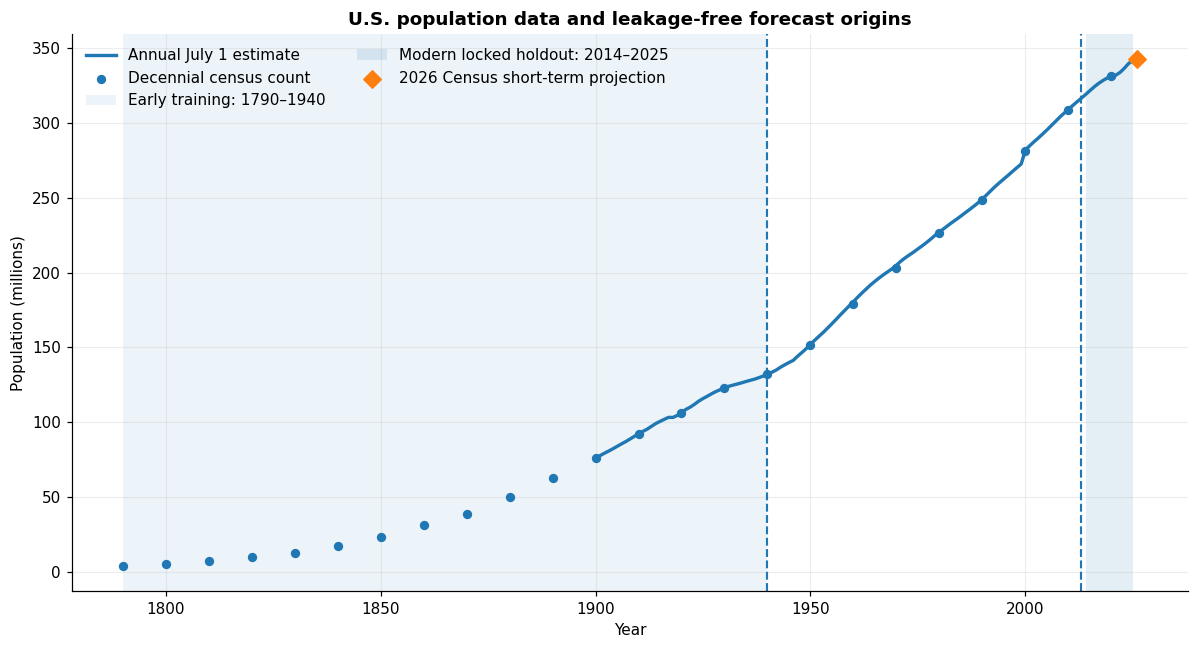

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(population_annual["year"], population_annual["population_millions"], lw=2.2, label="Annual July 1 estimate")
ax.scatter(population_decennial["year"], population_decennial["population_millions"], s=26, zorder=3, label="Decennial census count")
ax.axvspan(1790, 1940, alpha=0.08, label="Early training: 1790–1940")
ax.axvspan(2014, 2025, alpha=0.12, label="Modern locked holdout: 2014–2025")
ax.axvline(1940, ls="--", lw=1.4)
ax.axvline(2013, ls="--", lw=1.4)
ax.scatter([2026], [CENSUS_2026_SHORT_TERM_PROJECTION_M], marker="D", s=65, zorder=5, label="2026 Census short-term projection")
ax.set(title="U.S. population data and leakage-free forecast origins", xlabel="Year", ylabel="Population (millions)")
ax.legend(ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_data_and_splits.png", bbox_inches="tight")
plt.show()

## Results

# Experiment A — Can 1790–1940 predict through 2026?

### 4. Fit the exact logistic solution before using a PINN

For

\[
\frac{dP}{dt}=rP\left(1-\frac{P}{K}\right),
\]

the exact solution is

\[
P(t)=\frac{K}{1+A e^{-rt}}.
\]

**What this cell does.** It estimates \(K\), \(r\), and \(A\) from only the 1790–1940 observations and then extrapolates the exact curve through 2026.

**Why the exact curve must be fitted first.** The PINN and the analytic model impose the same physics. If both fail in the same way, the failure belongs to the fixed logistic assumption rather than to neural-network approximation. A PINN should not receive credit for reproducing behavior already implied by a closed-form solution.

In [4]:
def logistic_curve(t, K, r, A):
    t = np.asarray(t, dtype=float)
    return K / (1.0 + A * np.exp(-r * t))


def fit_logistic_exact(years, values_millions):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values_millions, dtype=float)
    t = years - years[0]
    K0 = max(values[-1] * 1.5, values.max() + 10)
    r0 = max(np.log(values[-1] / values[0]) / max(t[-1], 1), 1e-3)
    A0 = max(K0 / values[0] - 1, 1e-3)
    result = least_squares(
        lambda params: logistic_curve(t, *params) - values,
        x0=[K0, r0, A0],
        bounds=([values.max() * 1.000001, 1e-6, 1e-6], [3000.0, 0.30, 1e8]),
        max_nfev=50_000,
    )
    return result.x


def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = predicted - actual
    return {
        "RMSE_M": float(np.sqrt(np.mean(error**2))),
        "MAE_M": float(np.mean(np.abs(error))),
        "MAPE_pct": float(np.mean(np.abs(error / actual)) * 100),
    }

early_train = population_decennial.query("year <= 1940").copy()
early_test_decennial = population_decennial.query("1950 <= year <= 2020").copy()

early_K, early_r, early_A = fit_logistic_exact(
    early_train["year"], early_train["population_millions"]
)
early_year_grid = np.arange(1790, 2027)
early_exact_prediction = pd.Series(
    logistic_curve(early_year_grid - 1790, early_K, early_r, early_A),
    index=early_year_grid,
    name="Exact logistic",
)

early_train_metrics = regression_metrics(
    early_train["population_millions"], early_exact_prediction.loc[early_train["year"]]
)
early_test_metrics = regression_metrics(
    early_test_decennial["population_millions"], early_exact_prediction.loc[early_test_decennial["year"]]
)

early_exact_summary = pd.DataFrame([{
    "model": "Exact logistic, fit through 1940",
    "r_per_year": early_r,
    "K_millions": early_K,
    "train_RMSE_M": early_train_metrics["RMSE_M"],
    "1950_2020_RMSE_M": early_test_metrics["RMSE_M"],
    "pred_2020_M": early_exact_prediction.loc[2020],
    "pred_2025_M": early_exact_prediction.loc[2025],
    "pred_2026_M": early_exact_prediction.loc[2026],
}])
display(early_exact_summary.style.format(precision=3))

,model,r_per_year,K_millions,train_RMSE_M,1950_2020_RMSE_M,pred_2020_M,pred_2025_M,pred_2026_M
0,"Exact logistic, fit through 1940",0.032,185.699,0.845,88.521,180.350,181.126,181.267


### 5. Inspect the early logistic extrapolation

**What this cell does.** It overlays the pre-1940 fit, the post-1940 logistic forecast, and the observations that were hidden during fitting.

**How to read the figure.** The logistic curve looks convincing inside its calibration interval. Outside that interval it bends toward the fitted carrying capacity and becomes systematically too low. The unseen error is therefore the important result—not the attractive training fit.

> A model can interpolate the historical data very well and still be scientifically wrong for long-range extrapolation.

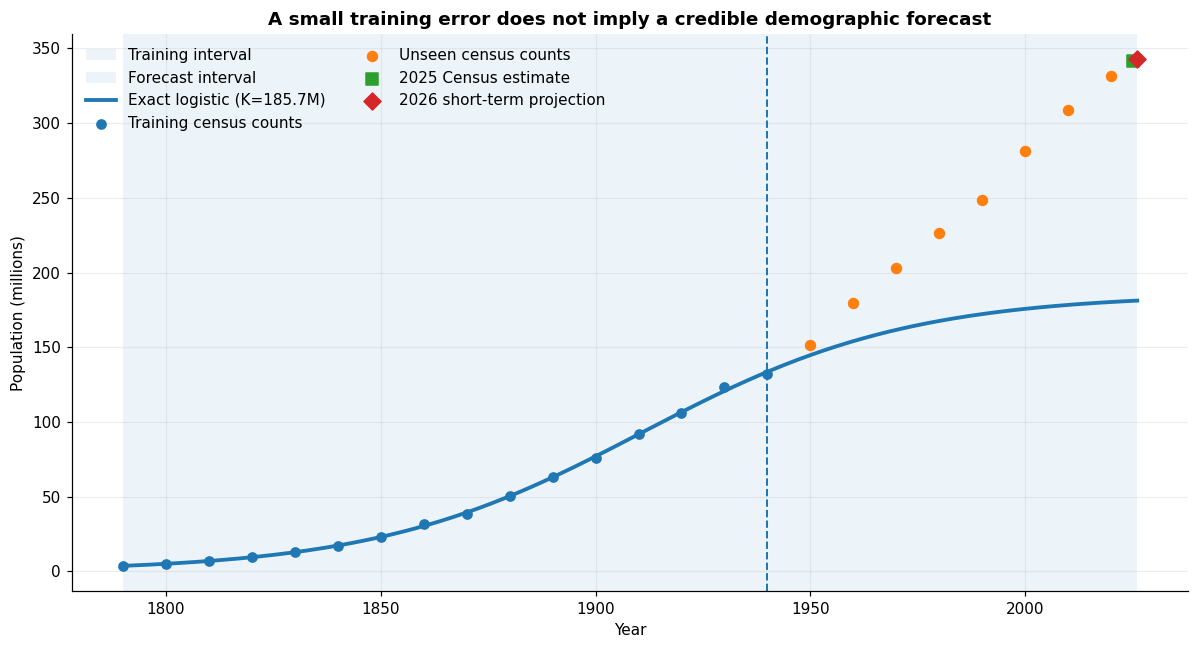

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(1790, 1940, alpha=0.08, label="Training interval")
ax.axvspan(1940, 2026, alpha=0.08, label="Forecast interval")
ax.plot(early_exact_prediction.index, early_exact_prediction.values, lw=2.5,
        label=f"Exact logistic (K={early_K:.1f}M)")
ax.scatter(early_train["year"], early_train["population_millions"], s=36, label="Training census counts", zorder=4)
ax.scatter(early_test_decennial["year"], early_test_decennial["population_millions"], s=42,
           label="Unseen census counts", zorder=4)
ax.scatter([2025], [population_annual.loc[2025, "population_millions"]], marker="s", s=58,
           label="2025 Census estimate", zorder=5)
ax.scatter([2026], [CENSUS_2026_SHORT_TERM_PROJECTION_M], marker="D", s=62,
           label="2026 short-term projection", zorder=5)
ax.axvline(1940, ls="--", lw=1.3)
ax.set(title="A small training error does not imply a credible demographic forecast",
       xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_early_logistic_failure.png", bbox_inches="tight")
plt.show()

### 6. Profile the carrying-capacity parameter

**What this cell does.** It fixes \(K\) across a wide grid, refits the remaining logistic parameters, and records both training RMSE and the implied 2026 forecast.

**Why this test is needed.** A common explanation for the failed forecast is that the early data simply do not identify the carrying capacity. The profile measures that uncertainty directly. It shows that several nearby values of \(K\) can fit the training period, but none of the well-fitting early regimes produces anything close to the later observed population.

The conclusion is stronger than “\(K\) is uncertain.” The constant-capacity model itself is not stable over the extrapolation horizon.

,result
best_K_M,186.0
K_range_with_RMSE_le_1M,178–196
2026_range_with_RMSE_le_1M_M,174.6–190.0


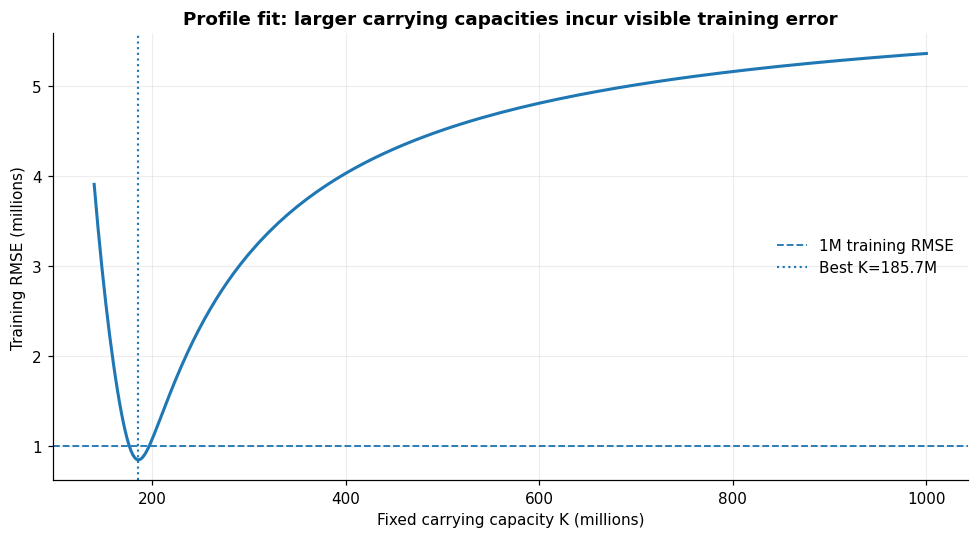

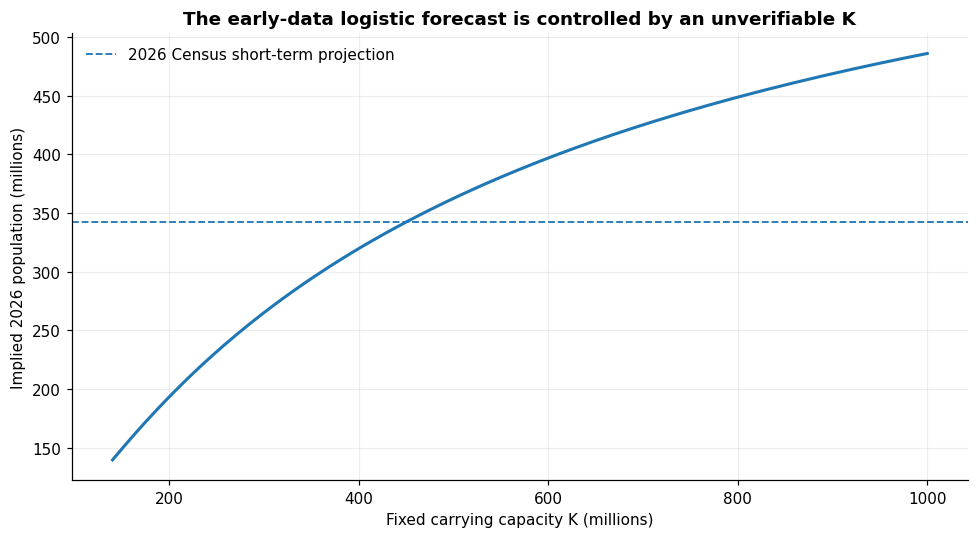

In [6]:
profile_rows = []
profile_K_grid = np.r_[np.linspace(140, 300, 81), np.linspace(310, 1000, 70)]
profile_t = early_train["year"].to_numpy() - 1790
profile_y = early_train["population_millions"].to_numpy()

for fixed_K in profile_K_grid:
    fit = least_squares(
        lambda params: logistic_curve(profile_t, fixed_K, params[0], params[1]) - profile_y,
        x0=[0.03, 50.0],
        bounds=([1e-6, 1e-6], [0.30, 1e8]),
        max_nfev=20_000,
    )
    r_value, A_value = fit.x
    fitted = logistic_curve(profile_t, fixed_K, r_value, A_value)
    profile_rows.append({
        "K_millions": fixed_K,
        "r_per_year": r_value,
        "train_RMSE_M": np.sqrt(np.mean((fitted - profile_y) ** 2)),
        "pred_2026_M": logistic_curve(2026 - 1790, fixed_K, r_value, A_value),
    })

capacity_profile = pd.DataFrame(profile_rows)
near_best = capacity_profile.query("train_RMSE_M <= 1.0")
profile_summary = pd.Series({
    "best_K_M": capacity_profile.loc[capacity_profile["train_RMSE_M"].idxmin(), "K_millions"],
    "K_range_with_RMSE_le_1M": f"{near_best.K_millions.min():.0f}–{near_best.K_millions.max():.0f}",
    "2026_range_with_RMSE_le_1M_M": f"{near_best.pred_2026_M.min():.1f}–{near_best.pred_2026_M.max():.1f}",
})
display(profile_summary.to_frame("result"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(capacity_profile["K_millions"], capacity_profile["train_RMSE_M"], lw=2)
ax.axhline(1.0, ls="--", lw=1.2, label="1M training RMSE")
ax.axvline(early_K, ls=":", lw=1.4, label=f"Best K={early_K:.1f}M")
ax.set(title="Profile fit: larger carrying capacities incur visible training error",
       xlabel="Fixed carrying capacity K (millions)", ylabel="Training RMSE (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_capacity_profile_fit.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(capacity_profile["K_millions"], capacity_profile["pred_2026_M"], lw=2)
ax.axhline(CENSUS_2026_SHORT_TERM_PROJECTION_M, ls="--", lw=1.2,
           label="2026 Census short-term projection")
ax.set(title="The early-data logistic forecast is controlled by an unverifiable K",
       xlabel="Fixed carrying capacity K (millions)", ylabel="Implied 2026 population (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "04_capacity_profile_forecast.png", bbox_inches="tight")
plt.show()

### 7. Define a logistic PINN with physics enforced through the forecast horizon

A common implementation error is to enforce the ODE only where data exist and then let the network extrapolate freely. This notebook instead evaluates the residual from the first observation through 2026.

\[
\mathcal{L}=\mathcal{L}_{data}+\lambda_{phys}\mathcal{L}_{ODE},
\qquad
\mathcal{L}_{ODE}=\frac{1}{N_r}\sum_j
\left[\frac{d\hat P}{dt}-r\hat P\left(1-\frac{\hat P}{K}\right)\right]^2.
\]

**Training stages**

1. Supervised warm start on the observed values.
2. Adam optimization of data and physics losses.
3. L-BFGS refinement.
4. For the adaptive model, evaluate a dense candidate grid, add separated high-residual points, and retrain.

Population and time are nondimensionalized for conditioning. The uniform and adaptive models use the same observations and equation; only the collocation strategy changes.

In [7]:
class LogisticPINN(nn.Module):
    def __init__(self, width=48):
        super().__init__()
        self.solution = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1),
        )
        self.raw_alpha = nn.Parameter(torch.tensor(1.0))
        self.raw_k = nn.Parameter(torch.tensor(0.0))

    def positive_parameters(self):
        alpha = torch.nn.functional.softplus(self.raw_alpha) + 1e-5
        k_scaled = 1.0 + torch.nn.functional.softplus(self.raw_k)
        return alpha, k_scaled

    def forward(self, x):
        return torch.exp(self.solution(x))


@dataclass
class PINNResult:
    prediction: pd.Series
    r_per_year: float
    K_millions: float
    residual_rmse: float
    residual_max_abs: float
    collocation_years: np.ndarray
    elapsed_seconds: float


def fit_logistic_pinn(
    years,
    values_millions,
    forecast_end=2026,
    adaptive=False,
    seed=7,
    initial_collocation=64,
    adaptive_rounds=3,
    add_per_round=12,
    epochs_per_round=700,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    years = np.asarray(years, dtype=float)
    values = np.asarray(values_millions, dtype=float)
    year_start, year_last = years[0], years[-1]
    span = year_last - year_start
    scale = values[-1]
    x_data = (years - year_start) / span
    q_data = values / scale
    x_forecast_max = (forecast_end - year_start) / span

    x_data_tensor = torch.tensor(x_data[:, None], dtype=torch.float32)
    q_data_tensor = torch.tensor(q_data[:, None], dtype=torch.float32)
    model = LogisticPINN()
    start = time.time()

    # Warm start: initialize the path before differentiating it.
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
    for _ in range(600):
        data_loss = ((model(x_data_tensor) - q_data_tensor) ** 2).mean()
        optimizer.zero_grad()
        data_loss.backward()
        optimizer.step()

    collocation = np.linspace(0, x_forecast_max, initial_collocation)[:, None]
    rounds = adaptive_rounds if adaptive else 0

    for round_index in range(rounds + 1):
        x_col = torch.tensor(collocation, dtype=torch.float32, requires_grad=True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        for _ in range(epochs_per_round):
            q_pred = model(x_col)
            dq_dx = torch.autograd.grad(q_pred, x_col, torch.ones_like(q_pred), create_graph=True)[0]
            alpha, k_scaled = model.positive_parameters()
            residual = dq_dx - alpha * q_pred * (1 - q_pred / k_scaled)
            data_loss = ((model(x_data_tensor) - q_data_tensor) ** 2).mean()
            physics_loss = (residual ** 2).mean()
            loss = 20.0 * data_loss + 5.0 * physics_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if adaptive and round_index < rounds:
            candidate = torch.linspace(0, x_forecast_max, 1501)[:, None].requires_grad_(True)
            q_candidate = model(candidate)
            dq_candidate = torch.autograd.grad(
                q_candidate, candidate, torch.ones_like(q_candidate), create_graph=False
            )[0]
            alpha, k_scaled = model.positive_parameters()
            candidate_residual = torch.abs(
                dq_candidate - alpha * q_candidate * (1 - q_candidate / k_scaled)
            ).detach().numpy().ravel()
            candidate_values = candidate.detach().numpy().ravel()

            selected = []
            min_existing_gap = 0.002 * x_forecast_max
            min_new_gap = 0.01 * x_forecast_max
            for index in np.argsort(candidate_residual)[::-1]:
                value = float(candidate_values[index])
                if (
                    np.min(np.abs(collocation.ravel() - value)) > min_existing_gap
                    and all(abs(value - other) > min_new_gap for other in selected)
                ):
                    selected.append(value)
                if len(selected) >= add_per_round:
                    break
            collocation = np.sort(np.r_[collocation.ravel(), selected])[:, None]

    # Deterministic quasi-Newton refinement.
    x_col = torch.tensor(collocation, dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        model.parameters(), lr=0.5, max_iter=300, history_size=50,
        line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()
        q_pred = model(x_col)
        dq_dx = torch.autograd.grad(q_pred, x_col, torch.ones_like(q_pred), create_graph=True)[0]
        alpha, k_scaled = model.positive_parameters()
        residual = dq_dx - alpha * q_pred * (1 - q_pred / k_scaled)
        data_loss = ((model(x_data_tensor) - q_data_tensor) ** 2).mean()
        physics_loss = (residual ** 2).mean()
        objective = 20.0 * data_loss + 5.0 * physics_loss
        objective.backward()
        return objective

    optimizer.step(closure)

    output_years = np.arange(int(year_start), int(forecast_end) + 1)
    x_output = torch.tensor(((output_years - year_start) / span)[:, None], dtype=torch.float32)
    with torch.no_grad():
        prediction = model(x_output).numpy().ravel() * scale
        alpha, k_scaled = model.positive_parameters()
        r_per_year = float(alpha.detach().numpy() / span)
        K_millions = float(k_scaled.detach().numpy() * scale)

    dense = torch.linspace(0, x_forecast_max, 2001)[:, None].requires_grad_(True)
    q_dense = model(dense)
    dq_dense = torch.autograd.grad(q_dense, dense, torch.ones_like(q_dense), create_graph=False)[0]
    alpha, k_scaled = model.positive_parameters()
    residual_dense = (
        dq_dense - alpha * q_dense * (1 - q_dense / k_scaled)
    ).detach().numpy().ravel()

    collocation_years = year_start + collocation.ravel() * span
    return PINNResult(
        prediction=pd.Series(prediction, index=output_years),
        r_per_year=r_per_year,
        K_millions=K_millions,
        residual_rmse=float(np.sqrt(np.mean(residual_dense ** 2))),
        residual_max_abs=float(np.max(np.abs(residual_dense))),
        collocation_years=collocation_years,
        elapsed_seconds=time.time() - start,
    )

### 8. Run uniform and residual-adaptive PINNs on the 1790–1940 information set

**What this cell does.** It trains a uniform-collocation PINN and a residual-adaptive PINN from the same 16 observations. Both enforce the logistic ODE through 2026.

**What would count as success.** Adaptive sampling is useful only if it improves the quantity we care about: unseen population forecasts. A smaller residual alone means the network follows the assumed equation more closely; it does not show that the equation matches reality.

In [8]:
early_uniform_pinn = fit_logistic_pinn(
    early_train["year"], early_train["population_millions"], adaptive=False
)
early_rar_pinn = fit_logistic_pinn(
    early_train["year"], early_train["population_millions"], adaptive=True
)

early_model_predictions = {
    "Exact logistic": early_exact_prediction,
    "Uniform PINN": early_uniform_pinn.prediction,
    "RAR PINN": early_rar_pinn.prediction,
}

early_comparison_rows = []
for name, prediction in early_model_predictions.items():
    if name == "Exact logistic":
        r_value, K_value, residual_value, n_col, elapsed = early_r, early_K, 0.0, np.nan, 0.0
    elif name == "Uniform PINN":
        result = early_uniform_pinn
        r_value, K_value, residual_value = result.r_per_year, result.K_millions, result.residual_rmse
        n_col, elapsed = len(result.collocation_years), result.elapsed_seconds
    else:
        result = early_rar_pinn
        r_value, K_value, residual_value = result.r_per_year, result.K_millions, result.residual_rmse
        n_col, elapsed = len(result.collocation_years), result.elapsed_seconds

    metrics = regression_metrics(
        early_test_decennial["population_millions"],
        prediction.loc[early_test_decennial["year"]],
    )
    early_comparison_rows.append({
        "model": name,
        "r_per_year": r_value,
        "K_millions": K_value,
        "ODE_residual_RMSE_scaled": residual_value,
        "collocation_points": n_col,
        "1950_2020_RMSE_M": metrics["RMSE_M"],
        "pred_2026_M": prediction.loc[2026],
        "seconds": elapsed,
    })

early_pinn_comparison = pd.DataFrame(early_comparison_rows).sort_values("1950_2020_RMSE_M")
display(early_pinn_comparison.style.format(precision=4))
early_pinn_comparison.to_csv(OUTPUT_DIR / "early_pinn_comparison.csv", index=False)

,model,r_per_year,K_millions,ODE_residual_RMSE_scaled,collocation_points,1950_2020_RMSE_M,pred_2026_M,seconds
0,Exact logistic,0.0322,185.6991,0.0000,nan,88.5205,181.2673,0.0000
1,Uniform PINN,0.0322,185.6023,0.0022,64.0000,88.5850,181.1701,1.8322
2,RAR PINN,0.0322,185.4044,0.0018,100.0000,88.6974,181.0097,3.3266


### 9. Inspect adaptive point placement and forecast equivalence

RAR adds points where the current neural approximation has the largest residual. In a difficult PDE this can be valuable because shocks, layers, or sharp gradients may be missed by uniform points.

Here the scalar logistic solution is smooth. Both PINNs converge toward essentially the same saturation curve as the analytic solution.

| Question | What answers it? | Result here |
|---|---|---|
| Did the network solve the logistic ODE? | Physics residual and agreement with the exact solution | Yes, approximately |
| Did the logistic ODE fit 1790–1940? | Training error | Yes |
| Did that ODE remain valid after 1940? | Hidden post-1940 forecast error | No |

Adaptive sampling helps mainly with the first row. The scientific failure occurs in the third.

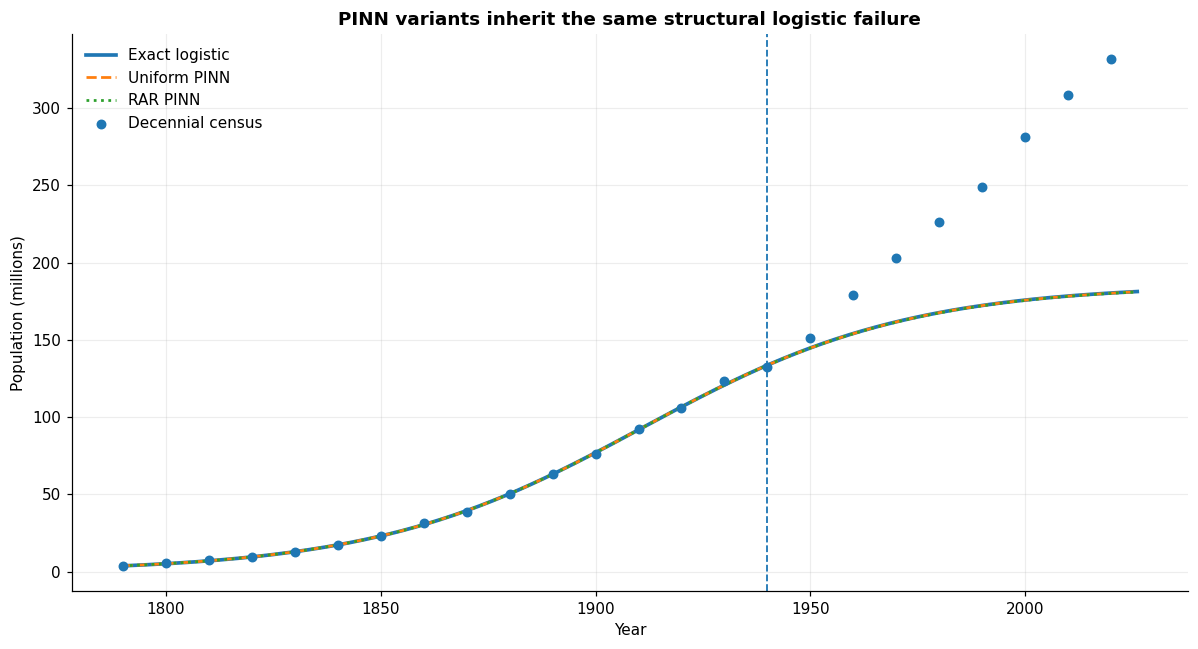

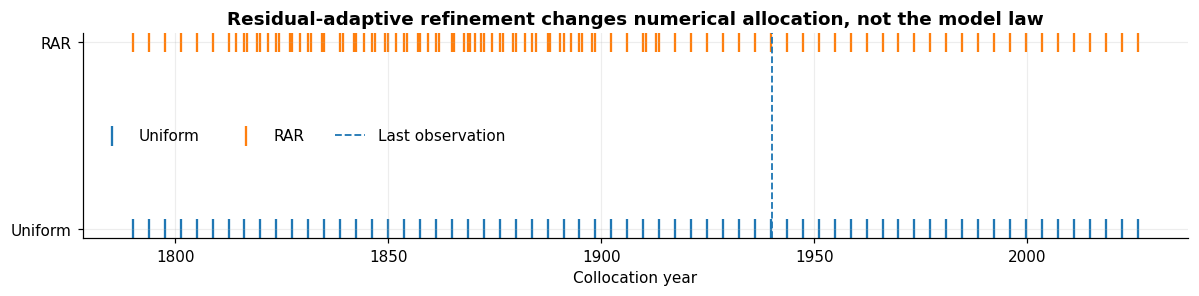

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(early_exact_prediction.index, early_exact_prediction.values, lw=2.4, label="Exact logistic")
ax.plot(early_uniform_pinn.prediction.index, early_uniform_pinn.prediction.values, lw=1.8, ls="--", label="Uniform PINN")
ax.plot(early_rar_pinn.prediction.index, early_rar_pinn.prediction.values, lw=1.8, ls=":", label="RAR PINN")
ax.scatter(population_decennial["year"], population_decennial["population_millions"], s=30, zorder=4, label="Decennial census")
ax.axvline(1940, ls="--", lw=1.2)
ax.set(title="PINN variants inherit the same structural logistic failure",
       xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_early_pinn_comparison.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.scatter(early_uniform_pinn.collocation_years, np.zeros_like(early_uniform_pinn.collocation_years),
           marker="|", s=180, label="Uniform")
ax.scatter(early_rar_pinn.collocation_years, np.ones_like(early_rar_pinn.collocation_years),
           marker="|", s=180, label="RAR")
ax.axvline(1940, ls="--", lw=1.2, label="Last observation")
ax.set(yticks=[0, 1], yticklabels=["Uniform", "RAR"], xlabel="Collocation year",
       title="Residual-adaptive refinement changes numerical allocation, not the model law")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_rar_collocation.png", bbox_inches="tight")
plt.show()

### Finding from Experiment A

The 1790–1940 information set supports only this counterfactual statement:

> **What would happen if the constant logistic law identified before 1940 continued unchanged?**

It does not support a credible forecast of the real U.S. population through 2026. The exact solution and both PINNs saturate near 181 million, while the later path rises far beyond that regime. Their unseen errors are nearly identical.

> **A PINN cannot repair a governing equation whose long-range assumptions are invalid.**

A more sophisticated optimizer, more collocation points, or a deeper network can make the neural solution more faithful to the logistic ODE. None of those changes supplies evidence that a constant \(r\) and constant \(K\) remain stable for another eight decades.

# Experiment B — What could have been forecast for 2014–2026 using only data through 2013?

### 10. Define transparent aggregate forecasting baselines

**What this cell does.** It defines an interpretable comparison set:

- local linear and log-linear trends;
- damped and undamped Holt trends;
- logistic and Gompertz saturation curves;
- a nonautonomous damped-growth ODE whose log-growth rate relaxes from \(g_0\) to \(g_\infty\).

Every model is refitted at every forecast origin. Candidate windows contain 10, 15, 20, 30, 40, 50, 60, or all available annual observations.

**Why non-PINN baselines are necessary.** A claim that a PINN forecasts well is incomplete unless it beats simpler models using the same information. The baselines reveal whether neural physics adds predictive value or only complexity.

In [10]:
annual_population = population_annual["population_millions"].copy()


def select_window(series, window):
    return series if window is None else series.tail(int(window))


def forecast_linear(series, forecast_years, window):
    sample = select_window(series, window)
    x = sample.index.to_numpy(dtype=float)
    coef = np.polyfit(x - x[-1], sample.to_numpy(), 1)
    return np.polyval(coef, np.asarray(forecast_years) - x[-1])


def forecast_log_linear(series, forecast_years, window):
    sample = select_window(series, window)
    x = sample.index.to_numpy(dtype=float)
    coef = np.polyfit(x - x[-1], np.log(sample.to_numpy()), 1)
    return np.exp(np.polyval(coef, np.asarray(forecast_years) - x[-1]))


def forecast_holt(series, forecast_years, window, damped):
    sample = select_window(series, window)
    fit = Holt(
        sample.to_numpy(), damped_trend=damped, initialization_method="estimated"
    ).fit(optimized=True, remove_bias=False)
    max_horizon = max(forecast_years) - sample.index[-1]
    path = fit.forecast(max_horizon)
    return np.array([path[year - sample.index[-1] - 1] for year in forecast_years])


def forecast_logistic(series, forecast_years, window):
    sample = select_window(series, window)
    K, r, A = fit_logistic_exact(sample.index.to_numpy(), sample.to_numpy())
    return logistic_curve(np.asarray(forecast_years) - sample.index[0], K, r, A)


def gompertz_curve(t, K, b, r):
    return K * np.exp(-b * np.exp(-r * np.asarray(t)))


def forecast_gompertz(series, forecast_years, window):
    sample = select_window(series, window)
    x = sample.index.to_numpy(dtype=float)
    t = x - x[0]
    y = sample.to_numpy()
    K0 = max(y[-1] * 1.5, y.max() + 10)
    result = least_squares(
        lambda params: gompertz_curve(t, *params) - y,
        x0=[K0, max(np.log(K0 / y[0]), 1e-4), 0.02],
        bounds=([y.max() * 1.000001, 1e-6, 1e-5], [3000, 100, 0.2]),
        max_nfev=20_000,
    )
    return gompertz_curve(np.asarray(forecast_years) - x[0], *result.x)


def damped_growth_curve(t, P0, g0, g_inf, decay):
    t = np.asarray(t, dtype=float)
    integrated_growth = g_inf * t + (g0 - g_inf) * (1 - np.exp(-decay * t)) / decay
    return P0 * np.exp(integrated_growth)


def forecast_damped_growth_ode(series, forecast_years, window):
    sample = select_window(series, window)
    x = sample.index.to_numpy(dtype=float)
    t = x - x[0]
    y = sample.to_numpy()
    annual_log_growth = np.diff(np.log(y))
    first = float(np.clip(np.mean(annual_log_growth[:min(5, len(annual_log_growth))]), 0, 0.05))
    last = float(np.clip(np.mean(annual_log_growth[-min(5, len(annual_log_growth)):]), 0, 0.05))
    result = least_squares(
        lambda params: damped_growth_curve(t, y[0], *params) - y,
        x0=[first, last, 0.05],
        bounds=([0.0, -0.02, 1e-4], [0.08, 0.05, 2.0]),
        max_nfev=20_000,
    )
    return damped_growth_curve(np.asarray(forecast_years) - x[0], y[0], *result.x)


MODEL_FUNCTIONS = {
    "Linear": forecast_linear,
    "Log-linear": forecast_log_linear,
    "Holt damped": lambda series, years, window: forecast_holt(series, years, window, True),
    "Holt undamped": lambda series, years, window: forecast_holt(series, years, window, False),
    "Logistic": forecast_logistic,
    "Gompertz": forecast_gompertz,
    "Damped-growth ODE": forecast_damped_growth_ode,
}

### 11. Select model families and history windows using only pre-2014 rolling origins

A 13-year horizon matches the intended 2014–2026 span. The notebook simulates historical deployments:

1. Train through 1970 and forecast 1971–1983.
2. Train through 1975 and forecast 1976–1988.
3. Continue at five-year origins through 2000, whose final target is 2013.
4. Rank every model/window configuration using only those pre-2014 errors.

The 2014–2025 period is untouched during selection.

**Why not use a random split?** Time-series forecasting must preserve chronology. Randomly mixing years would let the model learn from the future when predicting the past. Rolling origins imitate deployment and reveal whether a configuration is stable across historical regimes.

In [11]:
validation_origins = list(range(1970, 2001, 5))
validation_horizon = 13
candidate_windows = [10, 15, 20, 30, 40, 50, 60, None]

cv_rows = []
for model_name, forecast_function in MODEL_FUNCTIONS.items():
    for window in candidate_windows:
        errors = []
        valid = True
        for origin in validation_origins:
            training_series = annual_population.loc[:origin]
            if window is not None and len(training_series) < window:
                continue
            target_years = list(range(origin + 1, origin + validation_horizon + 1))
            try:
                prediction = np.asarray(forecast_function(training_series, target_years, window), dtype=float)
            except Exception:
                valid = False
                break
            actual = annual_population.loc[target_years].to_numpy()
            errors.extend(prediction - actual)
        if valid and errors:
            errors = np.asarray(errors)
            cv_rows.append({
                "model": model_name,
                "window": "all" if window is None else int(window),
                "CV_RMSE_M": np.sqrt(np.mean(errors ** 2)),
                "CV_MAE_M": np.mean(np.abs(errors)),
            })

cv_results = pd.DataFrame(cv_rows).sort_values("CV_RMSE_M").reset_index(drop=True)
best_configuration_per_model = (
    cv_results.loc[cv_results.groupby("model")["CV_RMSE_M"].idxmin()]
    .sort_values("CV_RMSE_M")
    .reset_index(drop=True)
)

display(Markdown("**Top pre-2014 configurations across all model/window combinations**"))
display(cv_results.head(15).style.format({"CV_RMSE_M": "{:.3f}", "CV_MAE_M": "{:.3f}"}))
display(Markdown("**Best window selected inside each model family**"))
display(best_configuration_per_model.style.format({"CV_RMSE_M": "{:.3f}", "CV_MAE_M": "{:.3f}"}))
cv_results.to_csv(OUTPUT_DIR / "rolling_origin_cv_results.csv", index=False)

**Top pre-2014 configurations across all model/window combinations**

,model,window,CV_RMSE_M,CV_MAE_M
0,Gompertz,all,2.807,2.507
1,Holt undamped,10,3.113,1.954
2,Log-linear,10,3.183,2.279
3,Holt undamped,20,3.186,2.002
4,Holt undamped,15,3.576,2.397
5,Holt undamped,30,3.759,2.352
6,Holt damped,15,3.766,2.504
7,Linear,10,3.805,2.430
8,Damped-growth ODE,20,4.011,2.756
9,Logistic,10,4.226,2.997


**Best window selected inside each model family**

,model,window,CV_RMSE_M,CV_MAE_M
0,Gompertz,all,2.807,2.507
1,Holt undamped,10,3.113,1.954
2,Log-linear,10,3.183,2.279
3,Holt damped,15,3.766,2.504
4,Linear,10,3.805,2.430
5,Damped-growth ODE,20,4.011,2.756
6,Logistic,10,4.226,2.997


### 12. Lock the selected configurations and score 2014–2025

This is the notebook's cleanest test of a forecast beginning in 2014.

- **Allowed for fitting and selection:** data through 2013.
- **Hidden final evaluation:** 2014–2025.
- **Forecast-only endpoint:** 2026.

The strict pre-2014 validation winner is locked before any holdout score is calculated. The notebook separately identifies the best model after looking at the holdout, but labels it **ex-post diagnostic**. This prevents choosing a method because it performed well on 2014–2025 and then presenting those same years as an unbiased test.

In [12]:
modern_training = annual_population.loc[:2013]
modern_holdout_years = list(range(2014, 2026))
modern_holdout_actual = annual_population.loc[modern_holdout_years].to_numpy()

holdout_rows = []
holdout_paths = {}
for _, selected in best_configuration_per_model.iterrows():
    model_name = selected["model"]
    window = None if selected["window"] == "all" else int(selected["window"])
    forecast_function = MODEL_FUNCTIONS[model_name]
    path_years = modern_holdout_years + [2026]
    prediction = np.asarray(forecast_function(modern_training, path_years, window), dtype=float)
    metrics = regression_metrics(modern_holdout_actual, prediction[:len(modern_holdout_years)])
    holdout_paths[model_name] = pd.Series(prediction, index=path_years)
    holdout_rows.append({
        "model": model_name,
        "selected_window": "all" if window is None else window,
        "pre_2014_CV_RMSE_M": selected["CV_RMSE_M"],
        "holdout_RMSE_M": metrics["RMSE_M"],
        "holdout_MAE_M": metrics["MAE_M"],
        "holdout_MAPE_pct": metrics["MAPE_pct"],
        "pred_2025_M": prediction[-2],
        "forecast_2026_from_2013_M": prediction[-1],
    })

modern_holdout_results = pd.DataFrame(holdout_rows).sort_values("holdout_RMSE_M").reset_index(drop=True)
display(modern_holdout_results.style.format(precision=3))
modern_holdout_results.to_csv(OUTPUT_DIR / "modern_holdout_results.csv", index=False)

cv_winner = best_configuration_per_model.iloc[0]
cv_winner_holdout = modern_holdout_results.query("model == @cv_winner.model").iloc[0]
ex_post_best = modern_holdout_results.iloc[0]
print(f"Strict pre-2014 CV winner: {cv_winner.model} ({cv_winner.window}-year window), "
      f"holdout RMSE={cv_winner_holdout.holdout_RMSE_M:.3f}M")
print(f"Ex-post holdout winner: {ex_post_best.model} ({ex_post_best.selected_window}-year window), "
      f"holdout RMSE={ex_post_best.holdout_RMSE_M:.3f}M")

,model,selected_window,pre_2014_CV_RMSE_M,holdout_RMSE_M,holdout_MAE_M,holdout_MAPE_pct,pred_2025_M,forecast_2026_from_2013_M
0,Logistic,10,4.226,0.901,0.761,0.229,340.975,342.620
1,Damped-growth ODE,20,4.011,2.105,1.695,0.508,343.662,345.461
2,Holt undamped,10,3.113,2.479,1.881,0.561,345.403,347.793
3,Holt damped,15,3.766,3.094,2.783,0.836,336.091,337.339
4,Linear,10,3.805,4.816,3.955,1.182,349.254,351.930
5,Log-linear,10,3.183,6.612,5.503,1.644,352.550,355.658
6,Gompertz,all,2.807,9.417,8.268,2.476,356.595,359.891


Strict pre-2014 CV winner: Gompertz (all-year window), holdout RMSE=9.417M
Ex-post holdout winner: Logistic (10-year window), holdout RMSE=0.901M


### 13. Plot the locked modern forecasts

**What this cell does.** It overlays the hidden 2014–2025 observations with forecasts produced from the 2013 information set.

**What the divergence means.** Several models fit the pre-2014 history reasonably well, yet their 12-year forecasts separate substantially. Long-horizon uncertainty includes uncertainty about the model family and historical window—not only parameter uncertainty inside one fitted curve.

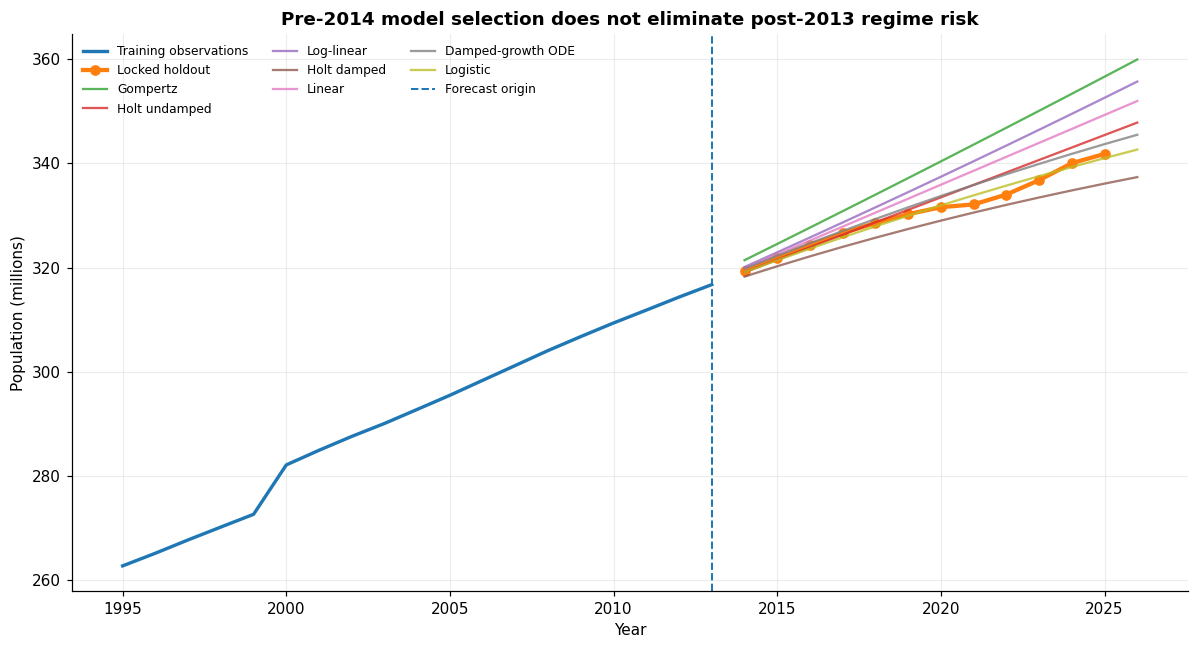

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(annual_population.loc[1995:2013].index, annual_population.loc[1995:2013].values,
        lw=2.2, label="Training observations")
ax.plot(modern_holdout_years, modern_holdout_actual, lw=2.8, marker="o", label="Locked holdout")
for model_name, path in holdout_paths.items():
    ax.plot(path.index, path.values, lw=1.5, alpha=0.78, label=model_name)
ax.axvline(2013, ls="--", lw=1.3, label="Forecast origin")
ax.set(title="Pre-2014 model selection does not eliminate post-2013 regime risk",
       xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "07_modern_holdout_paths.png", bbox_inches="tight")
plt.show()

### 14. Diagnose how much history the logistic curve should use

This is intentionally a **hindsight diagnostic**, not part of the clean pre-2014 selection.

**Question.** If the logistic family is fixed, how does its 2014–2025 error change when it uses the latest 10, 15, 20, 30, 40, 50, 60, or all annual observations through 2013?

“Use all the data” assumes that observations from very different eras estimate the same fixed parameters. Under nonstationarity, equal weighting of the distant past can bias the current regime.

The recent 10-year logistic fit scores about **0.90M RMSE**, while the all-history logistic fit scores about **7.45M**. Because the holdout revealed that result, it is evidence about nonstationarity—not a claim that the 10-year choice was known in advance.

,window,holdout_RMSE_M,holdout_MAE_M,pred_2025_M,forecast_2026_from_2013_M
0,10,0.901,0.761,340.975,342.620
2,20,0.940,0.775,340.130,341.658
1,15,3.647,3.263,334.997,336.096
7,all,7.449,6.408,353.467,356.476
6,60,8.730,7.549,355.660,358.909
3,30,10.295,9.198,357.654,360.944
5,50,10.758,9.416,358.989,362.572
4,40,11.516,10.189,360.032,363.668


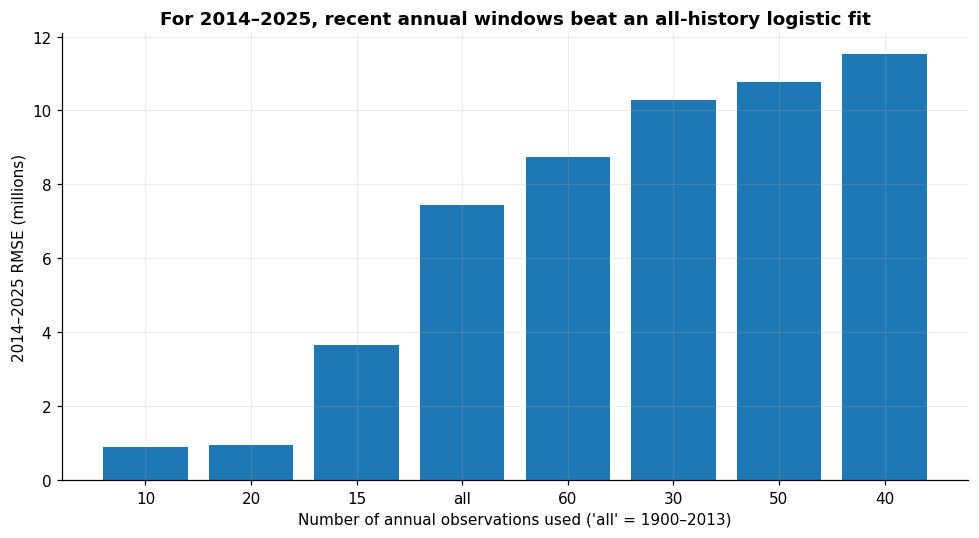

In [14]:
logistic_window_rows = []
for window in candidate_windows:
    prediction = np.asarray(
        forecast_logistic(modern_training, modern_holdout_years + [2026], window), dtype=float
    )
    metrics = regression_metrics(modern_holdout_actual, prediction[:-1])
    logistic_window_rows.append({
        "window": "all" if window is None else int(window),
        "holdout_RMSE_M": metrics["RMSE_M"],
        "holdout_MAE_M": metrics["MAE_M"],
        "pred_2025_M": prediction[-2],
        "forecast_2026_from_2013_M": prediction[-1],
    })

logistic_window_ablation = pd.DataFrame(logistic_window_rows).sort_values("holdout_RMSE_M")
display(logistic_window_ablation.style.format(precision=3))
logistic_window_ablation.to_csv(OUTPUT_DIR / "logistic_window_ablation.csv", index=False)

plot_ablation = logistic_window_ablation.copy()
plot_ablation["window_label"] = plot_ablation["window"].astype(str)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_ablation["window_label"], plot_ablation["holdout_RMSE_M"])
ax.set(title="For 2014–2025, recent annual windows beat an all-history logistic fit",
       xlabel="Number of annual observations used ('all' = 1900–2013)",
       ylabel="2014–2025 RMSE (millions)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "08_logistic_window_ablation.png", bbox_inches="tight")
plt.show()

### Interpreting the two “winners” without confusing validation and hindsight

| Result | Was 2014–2025 used to choose it? | 2014–2025 RMSE | Correct interpretation |
|---|---:|---:|---|
| Strict pre-2014 validation winner: all-history Gompertz | **No** | **9.42M** | What historical validation would have selected before 2014 |
| Recent 10-year logistic diagnostic | **Yes, for diagnosis** | **0.90M** | Evidence that the recent regime mattered more; not an unbiased selection result |
| Fixed recent-model median ensemble | Fixed independently of final ranking | **≈2.04M** | A more robust compromise across plausible recent-data assumptions |

The 0.90M result is informative, but it cannot be presented as if a forecaster in 2013 already knew that the 10-year logistic window would be best. The conclusion is about **data relevance and nonstationarity**, not one universally optimal curve.

### 15. PINN parity test on the recent 2004–2013 window

The recent 10-year logistic curve is the ex-post diagnostic winner, so it provides a second solver comparison.

All three methods use the same 2004–2013 observations, the same logistic equation, and physics enforced through 2026. If their paths overlap, the data window changed the fitted model while the neural solver added no new forecasting information.

In [15]:
recent_years = np.arange(2004, 2014, dtype=float)
recent_values = annual_population.loc[2004:2013].to_numpy()

modern_uniform_pinn = fit_logistic_pinn(recent_years, recent_values, adaptive=False)
modern_rar_pinn = fit_logistic_pinn(recent_years, recent_values, adaptive=True)

recent_exact_K, recent_exact_r, recent_exact_A = fit_logistic_exact(recent_years, recent_values)
recent_exact_path = pd.Series(
    logistic_curve(np.arange(2004, 2027) - 2004, recent_exact_K, recent_exact_r, recent_exact_A),
    index=np.arange(2004, 2027),
)

modern_pinn_rows = []
for name, path, r_value, K_value, residual, n_col in [
    ("Exact logistic", recent_exact_path, recent_exact_r, recent_exact_K, 0.0, np.nan),
    ("Uniform PINN", modern_uniform_pinn.prediction, modern_uniform_pinn.r_per_year,
     modern_uniform_pinn.K_millions, modern_uniform_pinn.residual_rmse,
     len(modern_uniform_pinn.collocation_years)),
    ("RAR PINN", modern_rar_pinn.prediction, modern_rar_pinn.r_per_year,
     modern_rar_pinn.K_millions, modern_rar_pinn.residual_rmse,
     len(modern_rar_pinn.collocation_years)),
]:
    metrics = regression_metrics(modern_holdout_actual, path.loc[modern_holdout_years])
    modern_pinn_rows.append({
        "model": name,
        "r_per_year": r_value,
        "K_millions": K_value,
        "ODE_residual_RMSE_scaled": residual,
        "collocation_points": n_col,
        "holdout_RMSE_M": metrics["RMSE_M"],
        "pred_2025_M": path.loc[2025],
        "forecast_2026_from_2013_M": path.loc[2026],
    })

modern_pinn_comparison = pd.DataFrame(modern_pinn_rows).sort_values("holdout_RMSE_M")
display(modern_pinn_comparison.style.format(precision=4))
modern_pinn_comparison.to_csv(OUTPUT_DIR / "modern_pinn_comparison.csv", index=False)

,model,r_per_year,K_millions,ODE_residual_RMSE_scaled,collocation_points,holdout_RMSE_M,pred_2025_M,forecast_2026_from_2013_M
1,Uniform PINN,0.0422,385.3091,0.0001,64.0000,0.8951,340.8526,342.4771
0,Exact logistic,0.0418,386.2408,0.0000,nan,0.9014,340.9746,342.6202
2,RAR PINN,0.0461,377.0780,0.0002,100.0000,1.0523,339.8158,341.3314


### 16. Visualize the modern PINN comparison

The exact curve, uniform PINN, and RAR PINN nearly overlap. Small differences come from optimization and finite neural approximation.

The research effort should therefore move away from making the same fixed logistic PINN deeper or adding collocation points to a smooth scalar solution. It should instead test a time-varying governing structure under a leakage-free validation design.

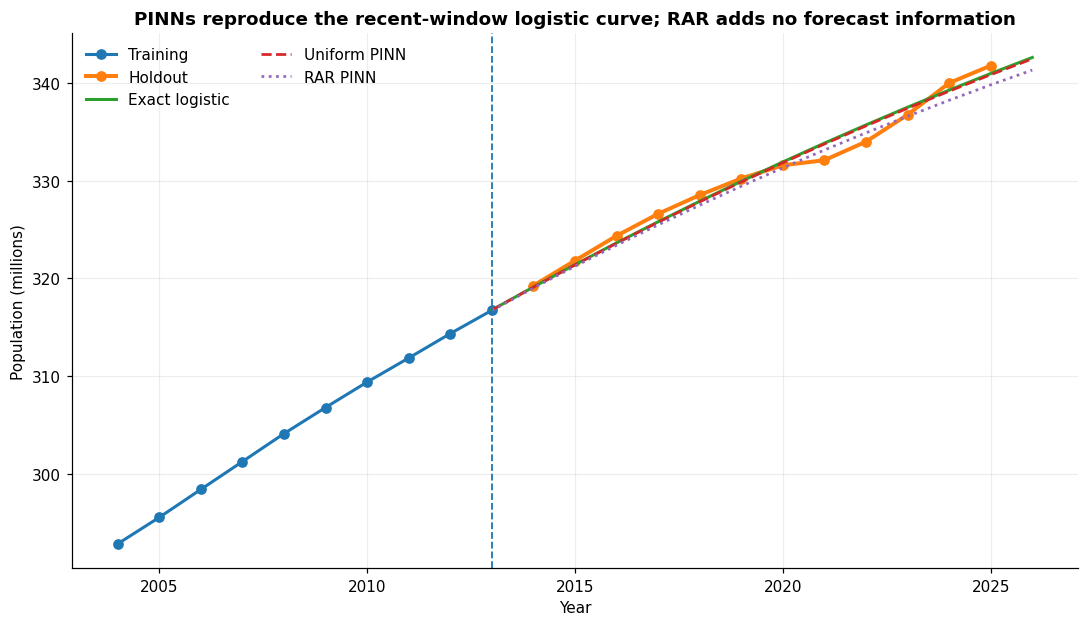

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(annual_population.loc[2004:2013].index, annual_population.loc[2004:2013].values,
        marker="o", lw=2, label="Training")
ax.plot(modern_holdout_years, modern_holdout_actual, marker="o", lw=2.6, label="Holdout")
ax.plot(recent_exact_path.loc[2013:2026], lw=2, label="Exact logistic")
ax.plot(modern_uniform_pinn.prediction.loc[2013:2026], ls="--", lw=1.8, label="Uniform PINN")
ax.plot(modern_rar_pinn.prediction.loc[2013:2026], ls=":", lw=1.8, label="RAR PINN")
ax.axvline(2013, ls="--", lw=1.2)
ax.set(title="PINNs reproduce the recent-window logistic curve; RAR adds no forecast information",
       xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "09_modern_pinn_parity.png", bbox_inches="tight")
plt.show()

# Experiment C — Can a DeepONet-style operator help with one national series?

### 17. Define a compact history-to-horizon DeepONet

DeepONet learns a map from an **input function** to an **output function**. Here:

- the branch network receives a normalized historical population window;
- the trunk network receives forecast horizon \(h/13\);
- their inner product predicts cumulative log growth.

History length is selected using targets only through 2013, and overlapping windows are treated as dependent samples. Windows such as 1950–1959, 1951–1960, and 1952–1961 are not three independent population systems; they are nearby views of the same trajectory.

In [17]:
class PopulationDeepONet(nn.Module):
    def __init__(self, branch_input, latent=16, width=32):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_input, width), nn.Tanh(), nn.Linear(width, latent)
        )
        self.trunk = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(), nn.Linear(width, latent)
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, trunk_input):
        return (self.branch(branch_input) * self.trunk(trunk_input)).sum(1, keepdim=True) + self.bias


def make_operator_samples(series, history_length, max_target_year, max_horizon=13):
    years = series.index.to_numpy()
    values = series.to_numpy()
    rows = []
    for origin_index in range(history_length - 1, len(values) - 1):
        history = np.log(values[origin_index - history_length + 1:origin_index + 1])
        branch_features = np.r_[history - history[-1], history[-1]]
        for horizon in range(1, max_horizon + 1):
            target_index = origin_index + horizon
            if target_index >= len(values) or years[target_index] > max_target_year:
                break
            target = np.log(values[target_index] / values[origin_index])
            rows.append((branch_features, horizon / max_horizon, target))
    branch = np.stack([row[0] for row in rows])
    trunk = np.array([row[1] for row in rows])[:, None]
    target = np.array([row[2] for row in rows])[:, None]
    return branch, trunk, target


def fit_population_deeponet(history_length, max_target_year, forecast_origin, epochs=1500):
    local_seed = 100 + history_length + max_target_year
    np.random.seed(local_seed)
    torch.manual_seed(local_seed)

    branch, trunk, target = make_operator_samples(
        annual_population, history_length, max_target_year
    )
    branch_mean, branch_std = branch.mean(0), branch.std(0) + 1e-6
    target_mean, target_std = target.mean(0), target.std(0) + 1e-6

    branch_tensor = torch.tensor((branch - branch_mean) / branch_std, dtype=torch.float32)
    trunk_tensor = torch.tensor(trunk, dtype=torch.float32)
    target_tensor = torch.tensor((target - target_mean) / target_std, dtype=torch.float32)

    model = PopulationDeepONet(branch.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-6)
    for epoch in range(epochs):
        prediction = model(branch_tensor, trunk_tensor)
        loss = ((prediction - target_tensor) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch in (750, 1150):
            for group in optimizer.param_groups:
                group["lr"] *= 0.3

    history = np.log(
        annual_population.loc[forecast_origin - history_length + 1:forecast_origin].to_numpy()
    )
    branch_feature = np.r_[history - history[-1], history[-1]]
    branch_forecast = torch.tensor(
        ((branch_feature - branch_mean) / branch_std)[None, :], dtype=torch.float32
    ).repeat(13, 1)
    trunk_forecast = torch.tensor((np.arange(1, 14) / 13)[:, None], dtype=torch.float32)
    with torch.no_grad():
        standardized = model(branch_forecast, trunk_forecast).numpy()
    cumulative_log_growth = (standardized * target_std + target_mean).ravel()
    forecast = annual_population.loc[forecast_origin] * np.exp(cumulative_log_growth)
    return forecast, len(branch), float(loss.detach().numpy())

### 18. Temporally validate history length, then run the locked DeepONet holdout

**What this cell does.** It compares history lengths on a validation path ending before 2014, locks one length, retrains with targets through 2013, and evaluates on 2014–2025.

The resulting holdout RMSE—about **19.6M**—shows that overlapping-window sample multiplication does not compensate for the absence of genuinely different trajectories.

In [18]:
operator_validation_rows = []
for history_length in [10, 15, 20, 30]:
    validation_forecast, sample_count, final_loss = fit_population_deeponet(
        history_length, max_target_year=2000, forecast_origin=2000
    )
    validation_actual = annual_population.loc[2001:2013].to_numpy()
    operator_validation_rows.append({
        "history_length": history_length,
        "dependent_training_pairs": sample_count,
        "network_training_loss": final_loss,
        "2001_2013_validation_RMSE_M": np.sqrt(np.mean((validation_forecast - validation_actual) ** 2)),
    })

operator_validation = pd.DataFrame(operator_validation_rows).sort_values(
    "2001_2013_validation_RMSE_M"
)
selected_history_length = int(operator_validation.iloc[0]["history_length"])
operator_forecast, operator_training_pairs, operator_loss = fit_population_deeponet(
    selected_history_length, max_target_year=2013, forecast_origin=2013
)
operator_holdout_metrics = regression_metrics(modern_holdout_actual, operator_forecast[:12])
operator_summary = pd.Series({
    "selected_history_length": selected_history_length,
    "dependent_training_pairs": operator_training_pairs,
    "2014_2025_holdout_RMSE_M": operator_holdout_metrics["RMSE_M"],
    "pred_2025_M": operator_forecast[11],
    "forecast_2026_from_2013_M": operator_forecast[12],
}, name="DeepONet-style operator")

display(operator_validation.style.format(precision=4))
display(operator_summary.to_frame("result"))
operator_validation.to_csv(OUTPUT_DIR / "deeponet_validation.csv", index=False)

,history_length,dependent_training_pairs,network_training_loss,2001_2013_validation_RMSE_M
0,10,1105,0.0120,6.9179
3,30,845,0.0030,16.8663
1,15,1040,0.0057,19.9241
2,20,975,0.0047,30.1961


,result
selected_history_length,10.000000
dependent_training_pairs,1274.000000
2014_2025_holdout_RMSE_M,19.575835
pred_2025_M,374.968262
forecast_2026_from_2013_M,380.159536


### 19. Compare the DeepONet path with stronger low-data baselines

The DeepONet forecast accelerates too strongly after 2013 and reaches roughly 375 million by 2025. It is not the best model for this dataset as currently formulated.

DeepONet becomes more defensible when training contains many distinct functions: many population histories, many initial conditions, or many time-varying coefficient paths generated by a validated model. In that setting it learns an operator. With one national trajectory, it mostly learns patterns in overlapping fragments.

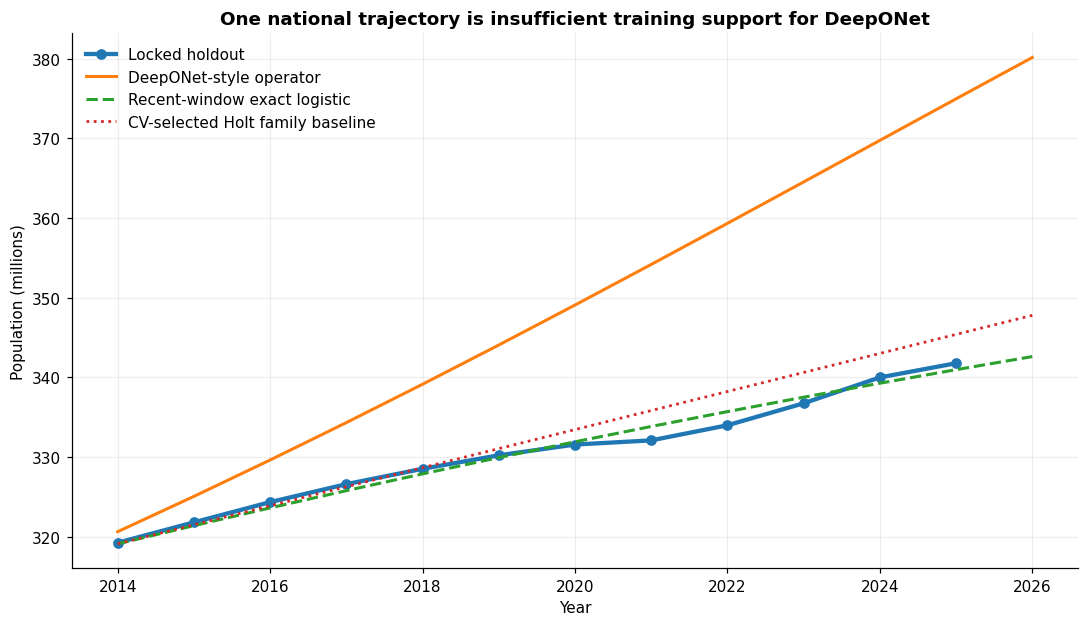

In [19]:
operator_path = pd.Series(operator_forecast, index=range(2014, 2027))
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(modern_holdout_years, modern_holdout_actual, marker="o", lw=2.8, label="Locked holdout")
ax.plot(operator_path.index, operator_path.values, lw=2, label="DeepONet-style operator")
ax.plot(recent_exact_path.loc[2014:2026], lw=2, ls="--", label="Recent-window exact logistic")
ax.plot(holdout_paths["Holt undamped"].index, holdout_paths["Holt undamped"].values,
        lw=1.8, ls=":", label="CV-selected Holt family baseline")
ax.set(title="One national trajectory is insufficient training support for DeepONet",
       xlabel="Year", ylabel="Population (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "10_deeponet_comparison.png", bbox_inches="tight")
plt.show()

# Proposed follow-up — a regime-aware inverse PINN

The executed experiments show that changing the solver does not fix a fixed-logistic model. The next defensible PINN study should change the coefficient structure and test it prospectively.

### Proposed model

Let the effective growth rate be a positive, slowly varying neural function,

\[
r_\phi(t)=\operatorname{softplus}(f_\phi(t)),
\]

and either keep \(K\) fixed over a short recent window or learn a positive, smooth \(K_\psi(t)\) with \(K_\psi(t)>P(t)\). Train the population and coefficient networks jointly.

### Proposed losses

- **Data loss:** match annual observations before the forecast origin.
- **Physics loss:** enforce the dynamic logistic residual across calibration and forecast domains.
- **Coefficient smoothness:** penalize rapid changes in \(r_\phi(t)\) and \(K_\psi(t)\).
- **Origin anchor:** match the final observed population and optionally its recent slope.
- **Ensemble reporting:** repeat training across seeds and bootstrap resamples.

### Proposed validation matrix

| Component | Candidate choices | Selection rule |
|---|---|---|
| History window | 10, 15, 20, 30, 40 years | Rolling origins ending before the final holdout |
| Coefficient structure | Constant \(r\); damped parametric \(r(t)\); neural \(r_\phi(t)\); neural \(r_\phi(t),K_\psi(t)\) | Out-of-origin RMSE plus coefficient stability |
| Collocation | Uniform, RAR, RAD | Forecast error first; residual reduction second |
| Regularization | Smoothness and positivity strengths | Nested temporal validation |
| Uncertainty | Multi-seed, bootstrap, conformal calibration | Historical coverage and interval width |

The dynamic PINN must improve untouched forecasts relative to the exact logistic curve, fixed-logistic PINNs, recent-window baselines, and the median ensemble. Stable coefficient functions across nearby origins are also required. Lower training loss alone is not enough.

# Operational 2026 forecast — use information available through 2025

### 20. Refit a robust recent-model ensemble at the correct forecast origin

This is separate from the 2013-origin retrospective test. Using 2025 data to claim a 2014 forecast would be leakage; using 2025 data to forecast 2026 is correct.

The notebook refits seven fixed recent-data configurations and takes their median. It calibrates a finite-sample empirical interval from one-year-ahead errors over origins 1980–2024.

**Why a median ensemble?** The members represent different assumptions about local trend and saturation. Their median is less sensitive to one unstable curve, while the historical error interval reflects more than the narrow spread of the current forecasts.

In [20]:
ENSEMBLE_CONFIGURATIONS = [
    ("Linear", 10),
    ("Log-linear", 10),
    ("Holt damped", 15),
    ("Holt undamped", 10),
    ("Logistic", 10),
    ("Gompertz", 10),
    ("Damped-growth ODE", 20),
]


def ensemble_one_step_forecast(training_series, target_year):
    member_forecasts = []
    member_names = []
    for model_name, window in ENSEMBLE_CONFIGURATIONS:
        forecast_value = float(MODEL_FUNCTIONS[model_name](training_series, [target_year], window)[0])
        member_forecasts.append(forecast_value)
        member_names.append(model_name)
    return float(np.median(member_forecasts)), pd.Series(member_forecasts, index=member_names)


one_step_rows = []
for origin in range(1980, 2025):
    point, _ = ensemble_one_step_forecast(annual_population.loc[:origin], origin + 1)
    actual = float(annual_population.loc[origin + 1])
    one_step_rows.append({
        "origin": origin,
        "target": origin + 1,
        "prediction_M": point,
        "actual_M": actual,
        "error_M": point - actual,
        "absolute_error_M": abs(point - actual),
    })

one_step_errors = pd.DataFrame(one_step_rows)
forecast_2026_ensemble_M, forecast_2026_members = ensemble_one_step_forecast(
    annual_population.loc[:2025], 2026
)

alpha = 0.10
sorted_absolute_errors = np.sort(one_step_errors["absolute_error_M"].to_numpy())
conformal_rank = min(math.ceil((len(sorted_absolute_errors) + 1) * (1 - alpha)), len(sorted_absolute_errors))
conformal_q90_M = float(sorted_absolute_errors[conformal_rank - 1])
forecast_2026_lower_M = forecast_2026_ensemble_M - conformal_q90_M
forecast_2026_upper_M = forecast_2026_ensemble_M + conformal_q90_M

forecast_2026_table = forecast_2026_members.rename("forecast_2026_M").to_frame()
forecast_2026_table.loc["Median ensemble"] = forecast_2026_ensemble_M
forecast_2026_table.loc["Census short-term projection"] = CENSUS_2026_SHORT_TERM_PROJECTION_M

display(forecast_2026_table.style.format("{:.3f}"))
print(f"Empirical one-step RMSE (1981–2025): "
      f"{np.sqrt(np.mean(one_step_errors.error_M ** 2)):.3f}M")
print(f"90% finite-sample empirical interval: "
      f"[{forecast_2026_lower_M:.3f}, {forecast_2026_upper_M:.3f}]M")
print(f"Difference from Census short-term projection: "
      f"{forecast_2026_ensemble_M - CENSUS_2026_SHORT_TERM_PROJECTION_M:+.3f}M")

one_step_errors.to_csv(OUTPUT_DIR / "one_step_ensemble_errors.csv", index=False)
forecast_2026_table.to_csv(OUTPUT_DIR / "forecast_2026_members.csv")

,forecast_2026_M
Linear,342.714
Log-linear,342.813
Holt damped,343.651
Holt undamped,343.722
Logistic,342.823
Gompertz,342.782
Damped-growth ODE,342.671
Median ensemble,342.813
Census short-term projection,342.620


Empirical one-step RMSE (1981–2025): 1.515M
90% finite-sample empirical interval: [340.505, 345.121]M
Difference from Census short-term projection: +0.193M


### 21. Inspect calibration errors and the 2026 result

The current ensemble projects **342.813 million** for 2026. Its finite-sample empirical 90% interval is **340.505–345.121 million**.

The Census short-term projection is an external benchmark only. It is not used to choose the ensemble, tune the interval, or score a nonexistent 2026 observation.

The interval is wider than the member spread because historical one-year errors include abrupt regime changes. Agreement among models fitted to the same recent data is not complete uncertainty quantification.

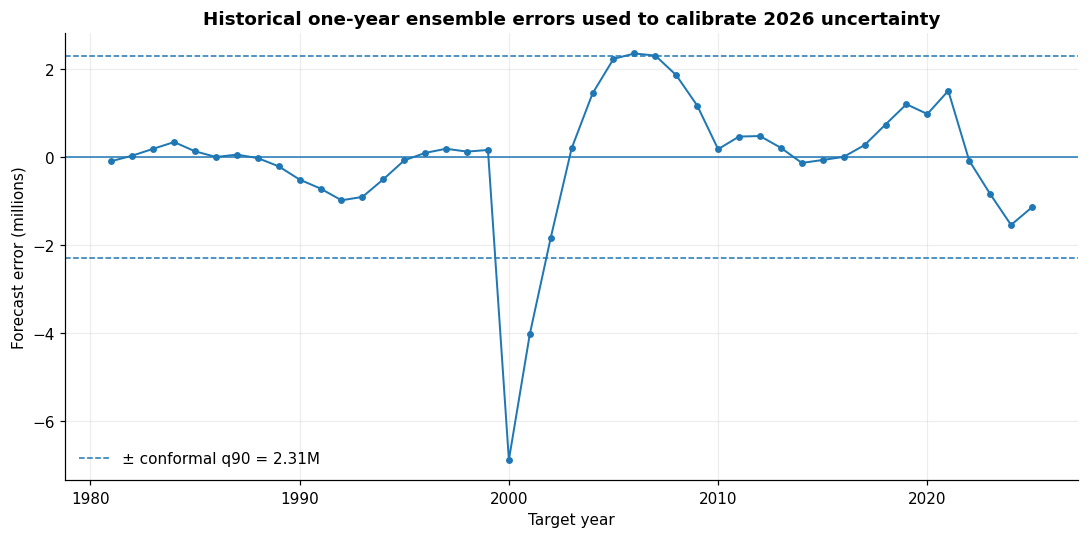

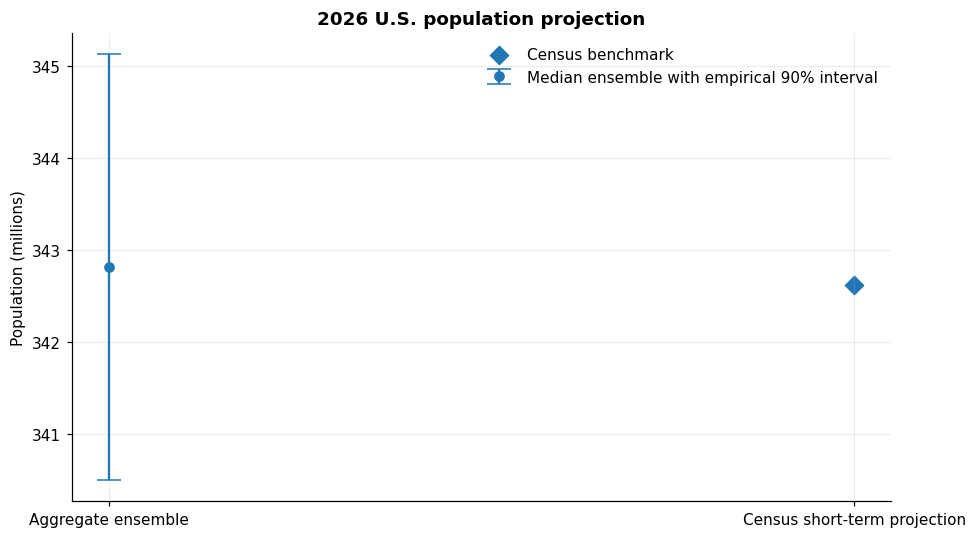

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, lw=1)
ax.plot(one_step_errors["target"], one_step_errors["error_M"], marker="o", ms=3.5, lw=1.3)
ax.axhline(conformal_q90_M, ls="--", lw=1, label=f"± conformal q90 = {conformal_q90_M:.2f}M")
ax.axhline(-conformal_q90_M, ls="--", lw=1)
ax.set(title="Historical one-year ensemble errors used to calibrate 2026 uncertainty",
       xlabel="Target year", ylabel="Forecast error (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "11_one_step_calibration_errors.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(["Aggregate ensemble"], [forecast_2026_ensemble_M],
            yerr=[[conformal_q90_M], [conformal_q90_M]], fmt="o", capsize=8,
            label="Median ensemble with empirical 90% interval")
ax.scatter(["Census short-term projection"], [CENSUS_2026_SHORT_TERM_PROJECTION_M], marker="D", s=70,
           label="Census benchmark")
ax.set(title="2026 U.S. population projection", ylabel="Population (millions)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "12_forecast_2026.png", bbox_inches="tight")
plt.show()

## Takeaways

### 22. PINN-centered model and data recommendation

| Goal | Recommended approach | Data design | Why |
|---|---|---|---|
| Test the historical logistic hypothesis | Exact logistic solution plus a PINN parity check | Historical calibration window and a strictly later test period | Separates model misspecification from neural approximation |
| Retrospective 2014–2026 aggregate forecast | Recent-window transparent models and a locked ensemble benchmark | Annual data through 2013; candidate 10–60 year windows; rolling origins ending by 2013 | Establishes a leakage-free baseline that a PINN must beat |
| Next PINN research model | **Regime-aware inverse PINN** with positive, slowly varying \(r_\phi(t)\) and optional \(K_\phi(t)\) | Start with recent 20–40 annual observations; select window and regularization before the final holdout | Directly addresses the fixed-parameter assumption that invalidated the original model |
| Adaptive sampling | RAR/RAD after the dynamic model is specified | Full forecast-domain candidate grid with extra points near high residual or rapid coefficient change | Improves numerical enforcement; does not replace model selection |
| Forecast uncertainty | Multi-seed PINN ensemble plus bootstrap or conformal calibration | Refit across rolling origins and retain out-of-origin errors | One neural trajectory understates optimization and regime uncertainty |
| DeepONet extension | Operator surrogate trained over many distinct trajectories or coefficient functions | Multiple populations or a large library of validated dynamic-PINN/ODE scenarios | Supplies the function-to-function diversity required for operator learning |
| Current 2026 benchmark | Median of fixed recent-window models refitted through 2025 | Latest internally consistent annual series | Transparent operational reference while the more flexible PINN is validated |

### A concrete next-generation PINN formulation

\[
\frac{dP}{dt}=r_\phi(t)P\left(1-\frac{P}{K_\phi(t)}\right),
\qquad r_\phi(t)>0,\quad K_\phi(t)>P(t).
\]

A possible objective is

\[
\mathcal{L}=\mathcal{L}_{data}
+\lambda_{phys}\mathcal{L}_{ODE}
+\lambda_r\left\|\frac{dr_\phi}{dt}\right\|_2^2
+\lambda_K\left\|\frac{dK_\phi}{dt}\right\|_2^2
+\lambda_{anchor}\mathcal{L}_{origin}.
\]

Smoothness prevents the coefficient networks from explaining every observation with arbitrary oscillations. The forecast-origin anchor keeps the predicted path continuous with the final observed year. Hyperparameters, network width, and history window must be selected on rolling origins ending before the final holdout.

This model is not guaranteed to win. It is the PINN experiment that directly addresses the failure found here. A valid claim requires it to beat the exact logistic curve, fixed PINNs, and recent-window ensemble on untouched forecast periods.

### Direct answers

**Can 1790–1940 predict 1940–2026?** Not as a credible real-world forecast under one constant logistic law. It can only produce a historical counterfactual.

**Why did the PINN fail?** The fixed governing equation failed outside its calibration regime. The neural solver reproduced that equation.

**Can adaptive sampling help?** It can improve residual enforcement in difficult regions. It cannot correct a structurally inadequate ODE.

**Can DeepONet help?** Not from overlapping windows of one national trajectory. It needs genuinely different input functions and output trajectories.

**What data should be used for a 2014-origin forecast?** Annual data through 2013, candidate recent windows, and rolling-origin validation ending by 2013. Keep 2014–2025 locked until final evaluation.

**What PINN should be tested next?** A regularized time-varying-coefficient inverse PINN, evaluated against transparent recent-window baselines and reported as an ensemble.

### 23. Consolidated quantitative decision table

**What this cell does.** It joins the central results—exact logistic, uniform PINN, RAR PINN, strict pre-2014 winner, ex-post recent logistic diagnostic, recent-model ensemble, DeepONet, and the current 2026 ensemble—into one table.

**Why this matters.** Every method is paired with its information set, evaluation period, RMSE, and 2026 projection where applicable. This prevents conclusions from being drawn from one attractive curve or one training loss.

In [22]:
# Ex-post aggregate ensemble on the 2013-origin holdout, for robustness context.
retrospective_member_paths = []
for model_name, window in ENSEMBLE_CONFIGURATIONS:
    retrospective_member_paths.append(
        MODEL_FUNCTIONS[model_name](modern_training, modern_holdout_years, window)
    )
retrospective_ensemble_path = np.median(np.asarray(retrospective_member_paths), axis=0)
retrospective_ensemble_metrics = regression_metrics(modern_holdout_actual, retrospective_ensemble_path)

key_results = pd.DataFrame([
    ["1790–1940 exact logistic", "1790–1940 decennial", "1950–2020 decennial", early_test_metrics["RMSE_M"], early_exact_prediction.loc[2026]],
    ["1790–1940 uniform PINN", "1790–1940 decennial", "1950–2020 decennial",
     early_pinn_comparison.query("model == 'Uniform PINN'").iloc[0]["1950_2020_RMSE_M"],
     early_uniform_pinn.prediction.loc[2026]],
    ["1790–1940 RAR PINN", "1790–1940 decennial", "1950–2020 decennial",
     early_pinn_comparison.query("model == 'RAR PINN'").iloc[0]["1950_2020_RMSE_M"],
     early_rar_pinn.prediction.loc[2026]],
    ["Strict CV winner", f"1900–2013; {cv_winner.window} window", "2014–2025",
     cv_winner_holdout.holdout_RMSE_M, cv_winner_holdout.forecast_2026_from_2013_M],
    ["Ex-post best aggregate curve", f"2004–2013; {ex_post_best.model}", "2014–2025",
     ex_post_best.holdout_RMSE_M, ex_post_best.forecast_2026_from_2013_M],
    ["Retrospective median ensemble", "fixed recent windows through 2013", "2014–2025",
     retrospective_ensemble_metrics["RMSE_M"], np.nan],
    ["DeepONet-style operator", f"pre-2014 windows; L={selected_history_length}", "2014–2025",
     operator_holdout_metrics["RMSE_M"], operator_forecast[12]],
    ["Current median ensemble", "annual data through 2025", "historical one-step calibration",
     np.sqrt(np.mean(one_step_errors.error_M ** 2)), forecast_2026_ensemble_M],
], columns=["method", "training_information", "evaluation", "RMSE_M", "2026_projection_M"])

display(key_results.style.format(precision=3))
key_results.to_csv(OUTPUT_DIR / "key_results.csv", index=False)

summary_payload = {
    "early_exact_test_rmse_m": float(early_test_metrics["RMSE_M"]),
    "early_exact_2026_m": float(early_exact_prediction.loc[2026]),
    "early_uniform_pinn_test_rmse_m": float(early_pinn_comparison.query("model == 'Uniform PINN'").iloc[0]["1950_2020_RMSE_M"]),
    "early_rar_pinn_test_rmse_m": float(early_pinn_comparison.query("model == 'RAR PINN'").iloc[0]["1950_2020_RMSE_M"]),
    "early_uniform_residual": float(early_uniform_pinn.residual_rmse),
    "early_rar_residual": float(early_rar_pinn.residual_rmse),
    "cv_winner_model": str(cv_winner.model),
    "cv_winner_window": str(cv_winner.window),
    "cv_winner_holdout_rmse_m": float(cv_winner_holdout.holdout_RMSE_M),
    "holdout_best_model": str(ex_post_best.model),
    "holdout_best_window": str(ex_post_best.selected_window),
    "holdout_best_rmse_m": float(ex_post_best.holdout_RMSE_M),
    "all_history_logistic_rmse_m": float(logistic_window_ablation.query("window == 'all'").iloc[0]["holdout_RMSE_M"]),
    "recent_10_logistic_rmse_m": float(logistic_window_ablation.query("window == 10").iloc[0]["holdout_RMSE_M"]),
    "modern_uniform_pinn_rmse_m": float(modern_pinn_comparison.query("model == 'Uniform PINN'").iloc[0]["holdout_RMSE_M"]),
    "modern_rar_pinn_rmse_m": float(modern_pinn_comparison.query("model == 'RAR PINN'").iloc[0]["holdout_RMSE_M"]),
    "deeponet_history": selected_history_length,
    "deeponet_holdout_rmse_m": float(operator_holdout_metrics["RMSE_M"]),
    "current_2026_ensemble_m": float(forecast_2026_ensemble_M),
    "current_2026_lower_m": float(forecast_2026_lower_M),
    "current_2026_upper_m": float(forecast_2026_upper_M),
    "census_2026_projection_m": float(CENSUS_2026_SHORT_TERM_PROJECTION_M),
    "retrospective_ensemble_rmse_m": float(retrospective_ensemble_metrics["RMSE_M"]),
}
with open(OUTPUT_DIR / "analysis_summary.json", "w") as handle:
    json.dump(summary_payload, handle, indent=2)

print(f"Saved {len(list(OUTPUT_DIR.iterdir()))} reproducibility artifacts to {OUTPUT_DIR.resolve()}")

,method,training_information,evaluation,RMSE_M,2026_projection_M
0,1790–1940 exact logistic,1790–1940 decennial,1950–2020 decennial,88.521,181.267
1,1790–1940 uniform PINN,1790–1940 decennial,1950–2020 decennial,88.585,181.170
2,1790–1940 RAR PINN,1790–1940 decennial,1950–2020 decennial,88.697,181.010
3,Strict CV winner,1900–2013; all window,2014–2025,9.417,359.891
4,Ex-post best aggregate curve,2004–2013; Logistic,2014–2025,0.901,342.620
5,Retrospective median ensemble,fixed recent windows through 2013,2014–2025,2.045,nan
6,DeepONet-style operator,pre-2014 windows; L=10,2014–2025,19.576,380.160
7,Current median ensemble,annual data through 2025,historical one-step calibration,1.515,342.813


Saved 22 reproducibility artifacts to /mnt/data/population_forecasting_outputs_revised


### Limitations

1. The annual series combines completed-decade intercensal estimates with Census Vintage 2025 values. Revisions can change historical estimates and backtest scores.
2. This is an aggregate univariate study. It tests what can be learned from the population trajectory alone; it does not claim that one scalar series contains every driver of future change.
3. The 2014–2025 holdout contains substantial regime variation. That makes it a useful stress test, but one holdout cannot establish universal superiority.
4. The recent 10-year logistic result is an ex-post diagnostic. It demonstrates that equal weighting of all history can be harmful, but it is not an unbiased pre-2014 selection result.
5. The proposed time-varying-coefficient inverse PINN is a research direction, not an executed winner in this notebook. It must be tested with the same temporal safeguards before any performance claim is made.
6. The empirical 2026 interval assumes historical one-year errors remain informative. It is not a complete probability model for every possible regime change.
7. The DeepONet experiment is a negative data-sufficiency diagnostic, not a definitive test of operator learning on a suitable multi-trajectory dataset.

### References and source files

1. Pearl, R. & Reed, L. J. (1920). *On the Rate of Growth of the Population of the United States Since 1790 and Its Mathematical Representation*. PNAS 6(6), 275–288. DOI: 10.1073/pnas.6.6.275.
2. Raissi, M., Perdikaris, P. & Karniadakis, G. E. (2019). *Physics-informed neural networks*. Journal of Computational Physics 378, 686–707. DOI: 10.1016/j.jcp.2018.10.045.
3. Wu, C., Zhu, M., Tan, Q., Kartha, Y. & Lu, L. (2023). *A comprehensive study of non-adaptive and residual-based adaptive sampling for physics-informed neural networks*. CMAME 403, 115671. DOI: 10.1016/j.cma.2022.115671.
4. Lu, L., Jin, P., Pang, G., Zhang, Z. & Karniadakis, G. E. (2021). *Learning nonlinear operators via DeepONet*. Nature Machine Intelligence 3, 218–229. DOI: 10.1038/s42256-021-00302-5.
5. Krishnapriyan, A. et al. (2021). *Characterizing possible failure modes in physics-informed neural networks*. NeurIPS 34.
6. U.S. Census Bureau population estimates and national totals used in the embedded offline snapshot. The Vintage 2025 monthly table labels dates after July 1, 2025 as short-term projections.

**Embedded source snapshot names:** `popclockest.txt`, `us-est00int-01.xls`, `nst-est2020int-pop.xlsx`, `NST-EST2025-POP.xlsx`, and `NA-EST2025-POP.xlsx`.